In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Input, Dense, LSTM, Dropout

warnings.filterwarnings('ignore', category=FutureWarning)

tf.random.set_seed(42)
np.random.seed(42)

In [2]:
sales = pd.read_csv('pedidos.csv', sep=';')

In [3]:
df_count = sales[['account_id', 'sales_channel_id']].value_counts()
df_count = pd.DataFrame(df_count).reset_index()

In [4]:
EPOCHS = 1000
BATCH_SIZE = 32
VALID_SPLIT = 0.1

In [5]:
ALL_SALES_CHANNELS = True
LOOKBACK = 3
CRIT_VALUE = 0.25
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [6]:
OOT_DATE = START_DATE + timedelta(hours=23)

In [7]:
OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [8]:
oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
df_oot = pd.DataFrame(index=oot_dates)

In [9]:
# ####
# sales.drop('sales_channel_id', axis=1, inplace=True)
# df = sales['account_id'].value_counts()
# df = pd.DataFrame(df).reset_index()

# df
# ####

Processing account_id: 8fa00df1-38eb-426f-81a6-1185983e14cb, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 81.4476 - val_loss: 6.9844e-04
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 81.4288 - val_loss: 9.3143e-04
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 81.4240 - val_loss: 2.3212e-04
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 81.4170 - val_loss: 2.4174e-04
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 81.4102 - val_loss: 2.6591e-04
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 81.4022 - val_loss: 6.8389e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch 1/1000
61/61 - 1s - 15ms/step - loss: 80.5221 - val_loss: 0.0035
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 80.5076 - val_loss: 2.5496e-04
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 80.5000 - val_loss: 6.4803e-04
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 80.4961 - val_loss: 3.8807e-04
Epoch 5/1000
61/61 - 0s - 3ms/step - loss: 80.4811 - val_loss: 4.17

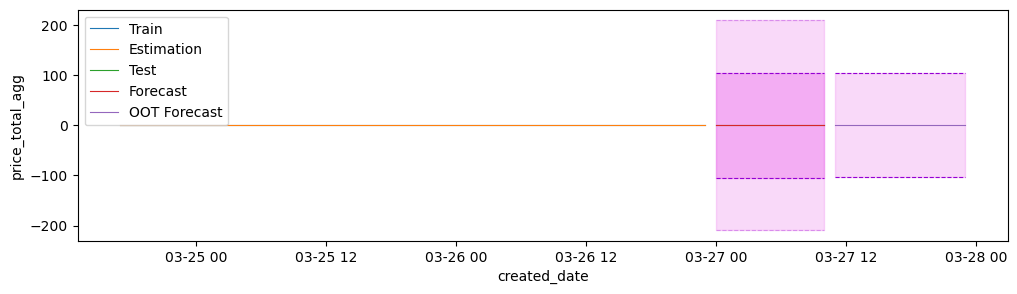

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 28ms/step - loss: 1.3543 - val_loss: 5.8010e-04
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 1.3364 - val_loss: 9.7743e-04
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 1.3290 - val_loss: 9.5853e-05
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.3204 - val_loss: 1.0344e-04
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.3149 - val_loss: 4.4013e-05
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.2976 - val_loss: 5.1075e-04
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.2940 - val_loss: 7.5882e-05
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.2755 - val_loss: 3.8878e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoch 1/1000
61/61 - 1s - 19ms/step - loss: 1.3312 - val_loss: 1.1068e-04
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 1.3183 - val_loss: 6.2211e-04
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 1.3077 - val_loss: 8.6404e-04
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 1.3034 - val_loss: 2.4220e-04
1/1 ━━━━━━━━━━━━━

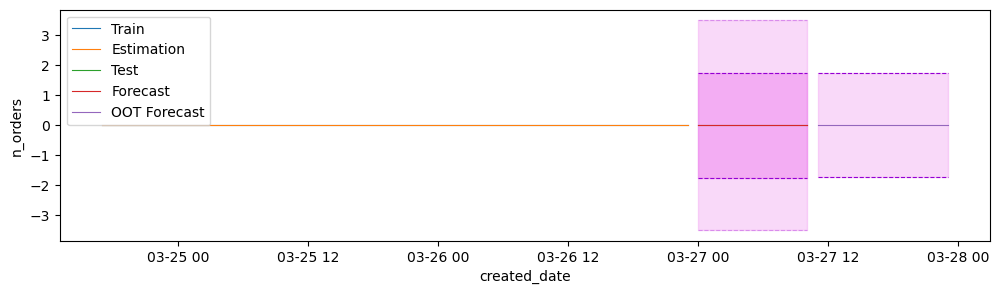

Processing account_id: 2058f680-aace-4b31-aed4-f34397b75096, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 19ms/step - loss: 0.0595 - val_loss: 1.1068e-04
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 0.0577 - val_loss: 1.6354e-04
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.0571 - val_loss: 6.9692e-05
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.0574 - val_loss: 4.9288e-05
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 0.0545 - val_loss: 4.6569e-05
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 0.0514 - val_loss: 5.6455e-05
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.0514 - val_loss: 5.0801e-05
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.0531 - val_loss: 1.1542e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 1/1000
61/61 - 1s - 17ms/step - loss: 0.0625 - val_loss: 1.2136e-04
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0574 - val_loss: 1.9196e-04
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 0.0573 - val_loss: 1.3680e-04


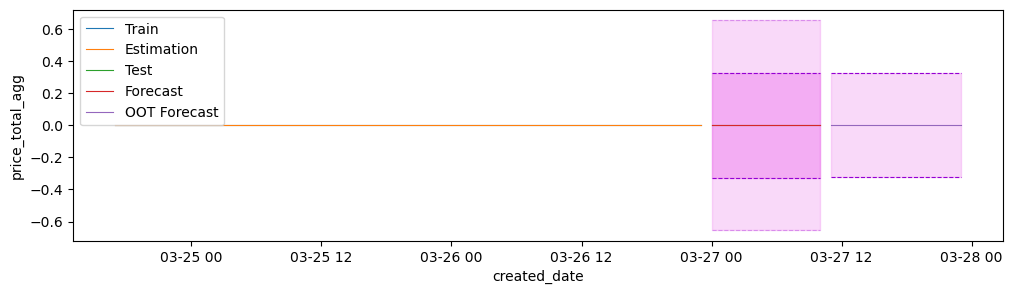

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 0.0255 - val_loss: 1.7082e-04
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0184 - val_loss: 4.9027e-05
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.0197 - val_loss: 1.0563e-04
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.0143 - val_loss: 9.1634e-05
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 0.0160 - val_loss: 6.6800e-05
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epoch 1/1000
61/61 - 1s - 14ms/step - loss: 0.0225 - val_loss: 1.3513e-04
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0169 - val_loss: 8.0832e-05
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 0.0173 - val_loss: 1.8705e-04
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 0.0175 - val_loss: 3.1791e-06
Epoch 5/1000
61/61 - 0s - 3ms/step - loss: 0.0148 - val_loss: 2.1469e-04
Epoch 6/1000
61/61 - 0s - 3ms/step - loss: 0.0175 - val_loss: 2.3930e-04
Epoch 7/1000
61/61 - 0s - 3ms/step - loss: 0.0142 - val_loss: 4.8991e-05
1/1 ━━━━━━━━━━━━━

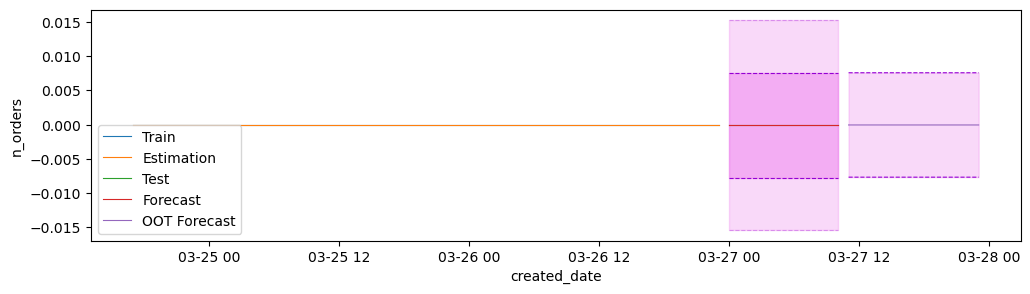

Processing account_id: aabe992c-cfad-4049-b5df-36c41f900a67, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 82.2469 - val_loss: 130.6377
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 82.2296 - val_loss: 130.6330
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 82.2217 - val_loss: 130.6223
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 82.2082 - val_loss: 130.6227
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 82.1882 - val_loss: 130.6097
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 82.1644 - val_loss: 130.5948
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 82.1228 - val_loss: 130.5674
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 82.0771 - val_loss: 130.5326
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 82.0233 - val_loss: 130.4863
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 81.9318 - val_loss: 130.4242
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 81.8527 - val_loss: 130.3512
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 81.7307 - val_loss: 130.2719
Epoch 13/1000


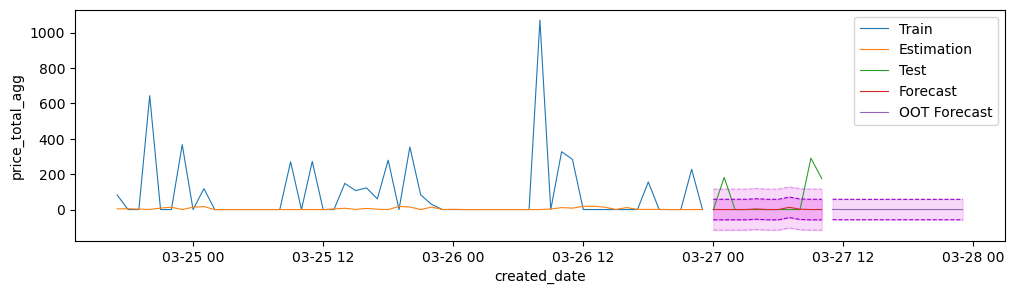

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 0.4199 - val_loss: 0.4823
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.4077 - val_loss: 0.4799
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.3993 - val_loss: 0.4800
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.3962 - val_loss: 0.4804
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.3898 - val_loss: 0.4775
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.3888 - val_loss: 0.4783
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 0.3859 - val_loss: 0.4778
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 0.3839 - val_loss: 0.4786
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Epoch 1/1000
61/61 - 1s - 10ms/step - loss: 0.4214 - val_loss: 0.4185
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.4106 - val_loss: 0.4175
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.4036 - val_loss: 0.4159
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.3970 - val_loss: 0.4164
Epoch 5/1000
61/61 - 0s - 1ms/step - loss: 0.3967 - val_loss: 0.4

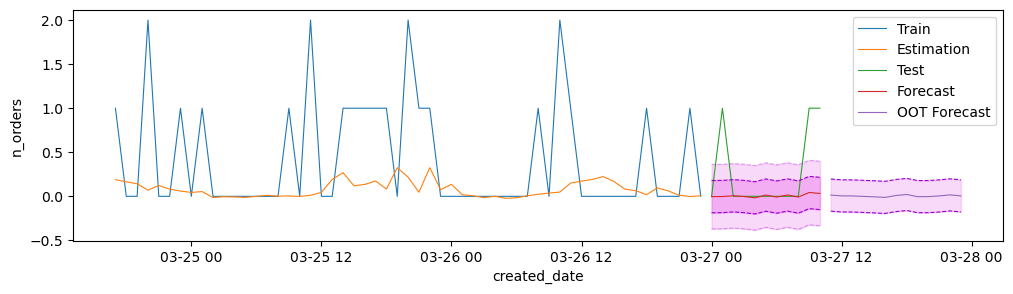

Processing account_id: b009c05b-326e-4ebe-988c-8d2229ec3a4c, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 822.6693 - val_loss: 617.3756
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 821.6466 - val_loss: 615.8444
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 818.1830 - val_loss: 611.6956
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 810.8002 - val_loss: 604.2177
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 799.7670 - val_loss: 593.4820
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 784.8438 - val_loss: 580.3699
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 768.9421 - val_loss: 566.0046
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 751.4522 - val_loss: 550.9108
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 732.7170 - val_loss: 536.7861
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 714.8466 - val_loss: 522.5475
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 698.2952 - val_loss: 509.6571
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 681.9170 - val_loss: 498.6048
Ep

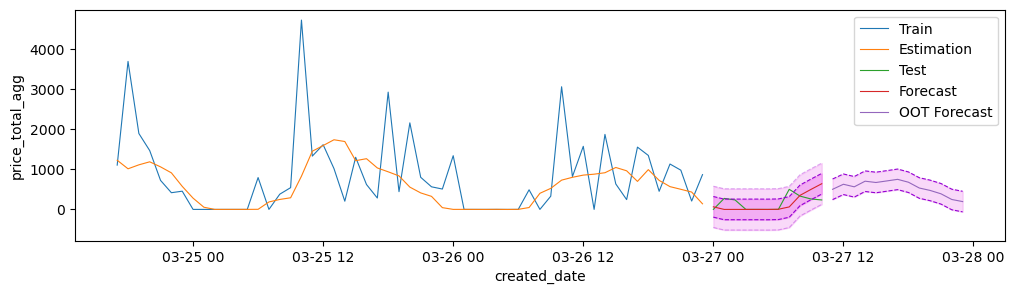

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 1.9553 - val_loss: 1.2773
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.4994 - val_loss: 1.0625
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.3819 - val_loss: 1.0394
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.3448 - val_loss: 1.0400
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.3280 - val_loss: 1.0383
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1.3240 - val_loss: 1.0392
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 1.3152 - val_loss: 1.0376
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.3359 - val_loss: 1.0397
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1.3147 - val_loss: 1.0436
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.3054 - val_loss: 1.0448
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Epoch 1/1000
61/61 - 1s - 14ms/step - loss: 1.8506 - val_loss: 1.1486
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 1.4114 - val_loss: 1.0616
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 1.3736 - val_loss: 1.

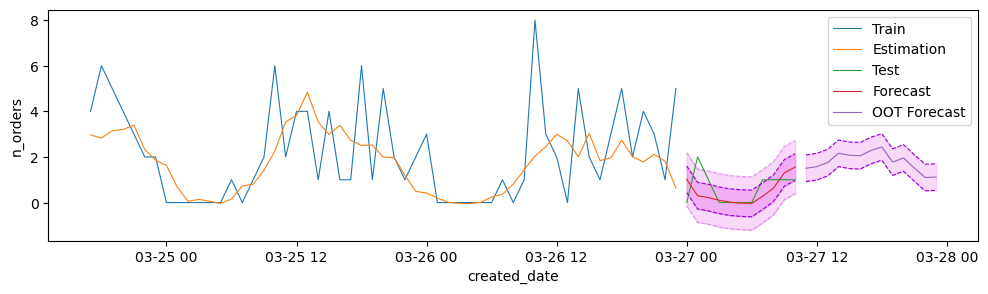

Processing account_id: 22fde42e-45d7-46cd-9d6f-3a4dbabbc579, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 261.6088 - val_loss: 251.4432
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 261.4343 - val_loss: 251.1818
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 261.0016 - val_loss: 250.5126
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 259.9568 - val_loss: 249.0943
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 258.1205 - val_loss: 246.7010
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 255.2681 - val_loss: 243.3978
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 252.0630 - val_loss: 239.8549
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 248.6164 - val_loss: 236.0280
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 245.6077 - val_loss: 232.4864
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 243.1965 - val_loss: 229.4741
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 241.0616 - val_loss: 227.1320
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 239.1241 - val_loss: 225.0442
Ep

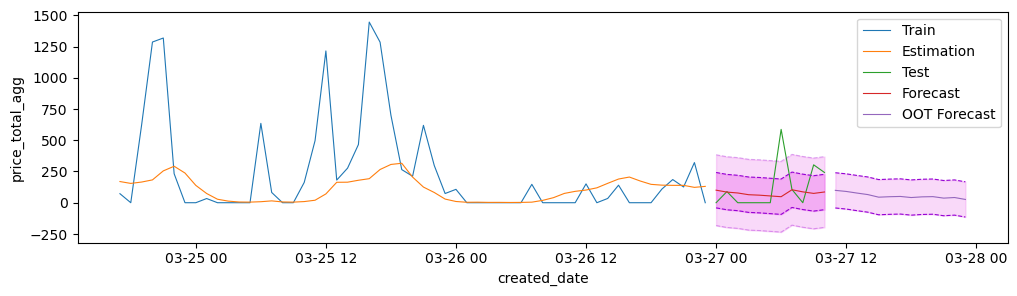

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 1.6544 - val_loss: 1.2287
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.5486 - val_loss: 1.1197
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.4447 - val_loss: 0.9889
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 1.3771 - val_loss: 0.9601
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 1.3452 - val_loss: 0.9444
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 1.3397 - val_loss: 0.9355
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.3258 - val_loss: 0.9307
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.3175 - val_loss: 0.9260
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1.2981 - val_loss: 0.9253
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.2920 - val_loss: 0.9203
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1.2961 - val_loss: 0.9252
Epoch 12/1000
60/60 - 0s - 5ms/step - loss: 1.2807 - val_loss: 0.9184
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 1.2788 - val_loss: 0.9201
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 1.2829 - val_loss: 0.9129


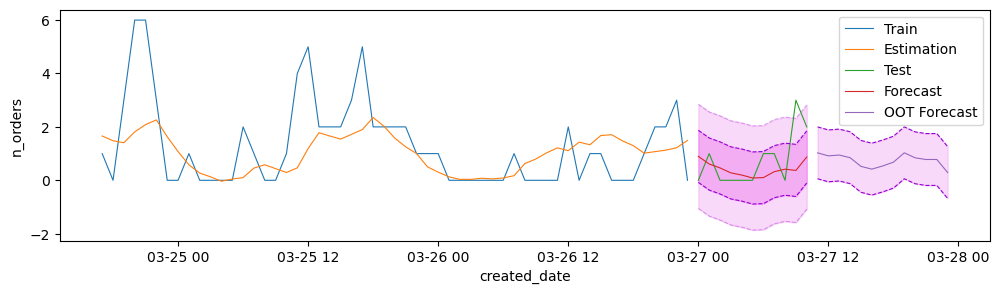

Processing account_id: 423a069b-27b8-44ed-9ef3-ca3cf9470970, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 77.9753 - val_loss: 9483.2510
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 77.9746 - val_loss: 9483.2354
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 77.9746 - val_loss: 9483.2285
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 77.9745 - val_loss: 9483.2051
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 77.9746 - val_loss: 9483.1855
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 77.9745 - val_loss: 9483.1680
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 77.9745 - val_loss: 9483.1465
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 77.9745 - val_loss: 9483.1084
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 77.9745 - val_loss: 9483.0674
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 77.9744 - val_loss: 9483.0088
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 77.9744 - val_loss: 9482.9404
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 77.9743 - val_loss: 9482.8730
Ep

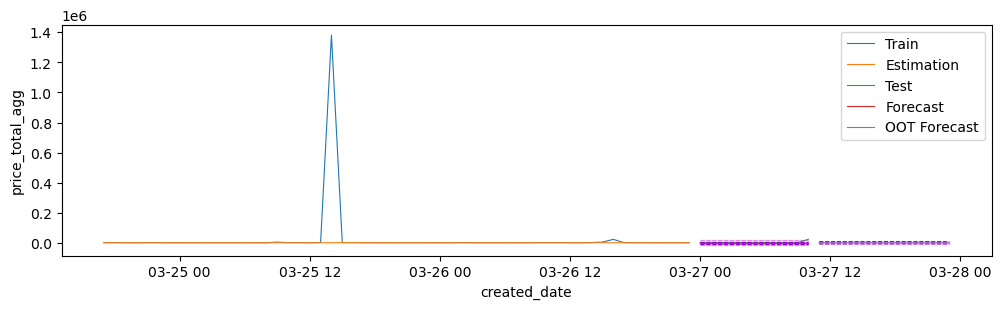

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 0.3624 - val_loss: 221.1199
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.1135
Epoch 3/1000
60/60 - 0s - 6ms/step - loss: 0.3619 - val_loss: 221.1125
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.1102
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.1088
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.1086
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 0.3620 - val_loss: 221.1076
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.1036
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.1030
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.0997
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 221.0995
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.0987
Epoch 13/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 221.0988
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 

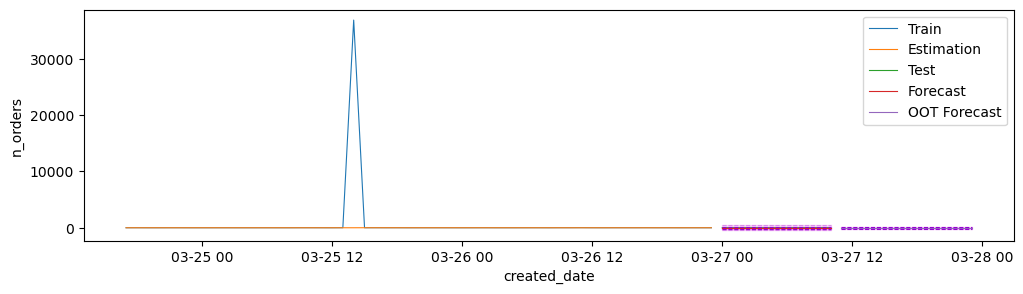

Processing account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Epoch 1/1000
61/61 - 1s - 12ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/st

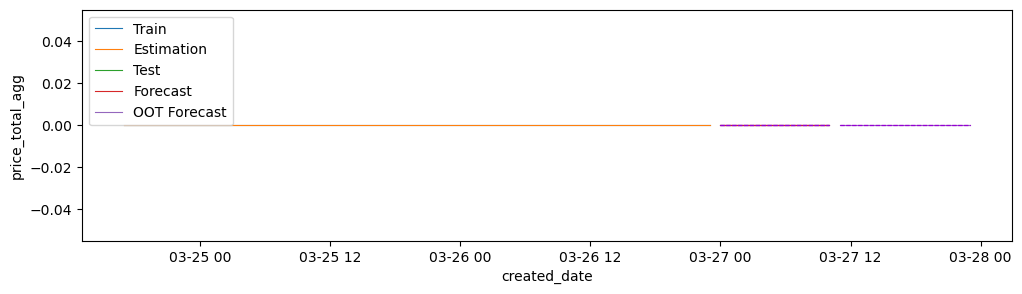

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Epoch 1/1000
61/61 - 1s - 14ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━

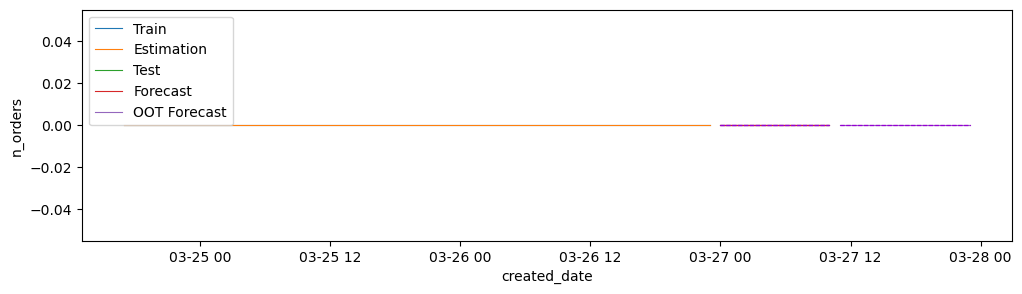

Processing account_id: 7412074f-0f3a-4724-b035-7fb4db3174c8, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 970.1049 - val_loss: 703.3466
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 969.7132 - val_loss: 703.2979
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 968.8157 - val_loss: 703.2482
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 967.0279 - val_loss: 703.2470
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 964.1111 - val_loss: 703.3568
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 959.5336 - val_loss: 703.6067
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 953.5483 - val_loss: 704.0098
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoch 1/1000
61/61 - 1s - 16ms/step - loss: 973.7015 - val_loss: 564.8137
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 973.1679 - val_loss: 564.9243
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 972.0168 - val_loss: 565.2457
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 969.6799 - val_loss: 565.9935


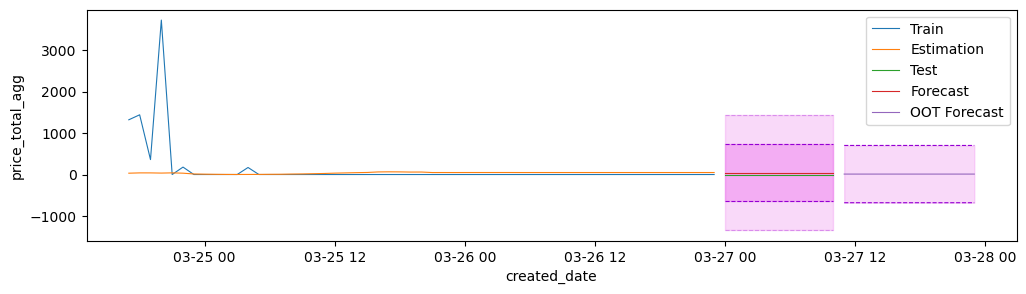

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 2.2478 - val_loss: 1.6560
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 1.8566 - val_loss: 1.7132
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.5982 - val_loss: 1.8163
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 1.5146 - val_loss: 1.7604
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch 1/1000
61/61 - 1s - 10ms/step - loss: 2.2087 - val_loss: 1.4422
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 1.7894 - val_loss: 1.6511
Epoch 3/1000
61/61 - 0s - 1ms/step - loss: 1.5815 - val_loss: 1.8164
Epoch 4/1000
61/61 - 0s - 1ms/step - loss: 1.5066 - val_loss: 1.7896
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

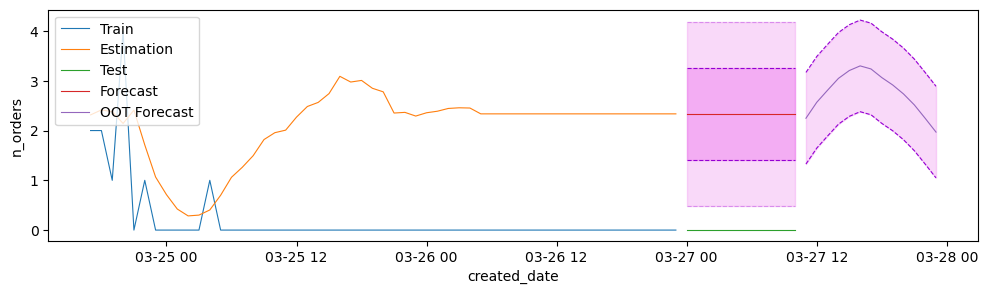

Processing account_id: 5dd8b3ee-6f1c-4ac9-bbc5-91829dde38eb, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 5113.6646 - val_loss: 3986.7605
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 5112.7095 - val_loss: 3985.3130
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 5109.9116 - val_loss: 3981.4055
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 5103.8403 - val_loss: 3973.7966
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 5093.5977 - val_loss: 3962.2495
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 5079.5205 - val_loss: 3947.0308
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 5061.7251 - val_loss: 3928.3252
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 5041.2275 - val_loss: 3906.4050
Epoch 9/1000
60/60 - 0s - 6ms/step - loss: 5016.1138 - val_loss: 3880.7383
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 4987.0327 - val_loss: 3851.7234
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 4956.2764 - val_loss: 3819.5732
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 4918.4531 

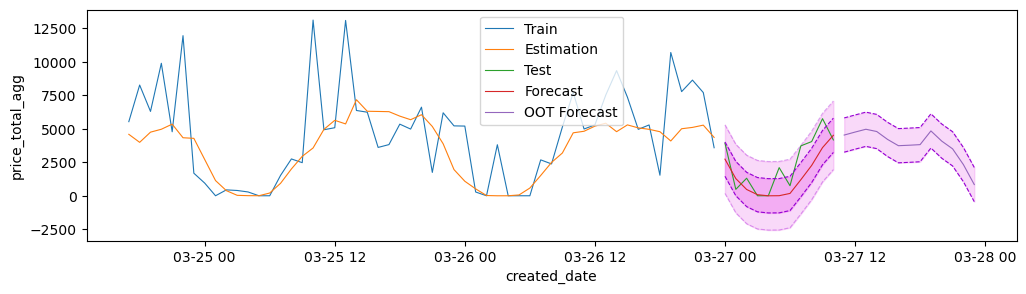

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 12.1267 - val_loss: 7.7581
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 11.1095 - val_loss: 6.1935
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 8.8892 - val_loss: 3.9835
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 6.2049 - val_loss: 3.2594
Epoch 5/1000
60/60 - 0s - 7ms/step - loss: 5.2551 - val_loss: 3.1163
Epoch 6/1000
60/60 - 0s - 5ms/step - loss: 5.1135 - val_loss: 3.0879
Epoch 7/1000
60/60 - 0s - 5ms/step - loss: 5.0286 - val_loss: 3.0613
Epoch 8/1000
60/60 - 0s - 8ms/step - loss: 4.9586 - val_loss: 3.0576
Epoch 9/1000
60/60 - 1s - 10ms/step - loss: 4.9721 - val_loss: 3.0635
Epoch 10/1000
60/60 - 0s - 7ms/step - loss: 4.9053 - val_loss: 3.0705
Epoch 11/1000
60/60 - 1s - 11ms/step - loss: 4.8722 - val_loss: 3.0556
Epoch 12/1000
60/60 - 1s - 15ms/step - loss: 4.8033 - val_loss: 3.0423
Epoch 13/1000
60/60 - 0s - 5ms/step - loss: 4.7702 - val_loss: 3.0508
Epoch 14/1000
60/60 - 0s - 4ms/step - loss: 4.7761 - val_loss: 3.

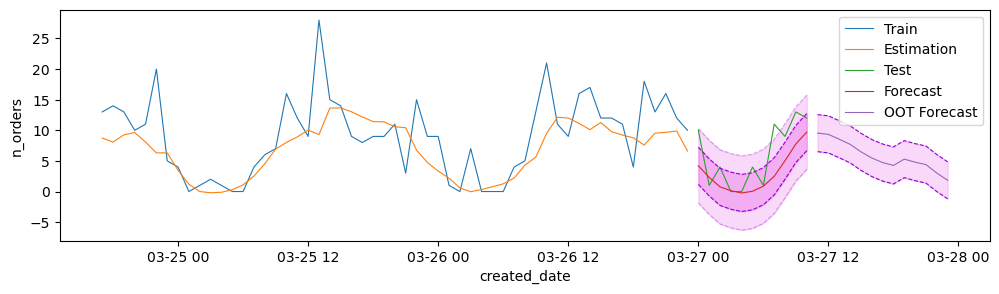

Processing account_id: adc6fb62-09e7-44fd-a619-f787ecfd140b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 899.6066 - val_loss: 753.2612
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 897.7350 - val_loss: 751.0654
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 892.0976 - val_loss: 745.5021
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 881.3488 - val_loss: 736.0907
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 865.4969 - val_loss: 723.1912
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 844.9178 - val_loss: 706.8820
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 820.0475 - val_loss: 687.9406
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 792.0932 - val_loss: 666.8061
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 764.1055 - val_loss: 647.1541
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 733.9715 - val_loss: 628.2801
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 706.9310 - val_loss: 609.6060
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 679.7717 - val_loss: 593.0023
Ep

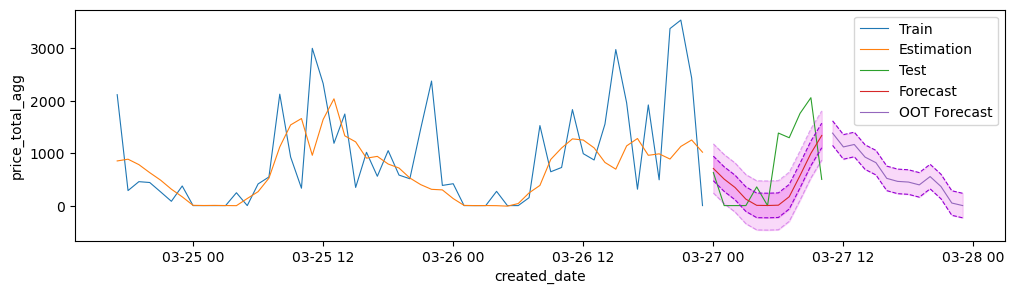

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 3.1418 - val_loss: 2.1398
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 2.0302 - val_loss: 1.6113
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.8227 - val_loss: 1.5853
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 1.7953 - val_loss: 1.5740
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1.7545 - val_loss: 1.5719
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1.7458 - val_loss: 1.5788
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 1.7291 - val_loss: 1.5713
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1.7266 - val_loss: 1.5925
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1.6690 - val_loss: 1.5829
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 1.6799 - val_loss: 1.5876
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 1/1000
61/61 - 1s - 13ms/step - loss: 3.0752 - val_loss: 2.0051
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 1.9558 - val_loss: 1.6554
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 1.7765 - val_loss: 1.

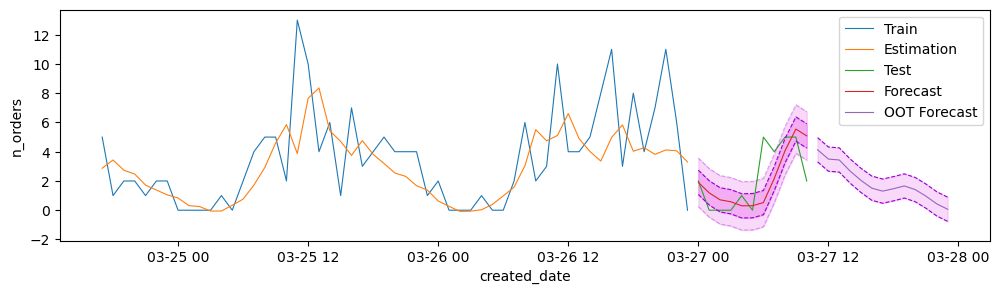

Processing account_id: 74abffac-6542-4eff-8eae-cc85463a5d02, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 2556.9897 - val_loss: 2884.3979
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 2553.7769 - val_loss: 2878.7219
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 2544.5852 - val_loss: 2865.6948
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 2527.6309 - val_loss: 2844.6538
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 2502.5432 - val_loss: 2816.2439
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 2471.0339 - val_loss: 2781.8516
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 2434.0264 - val_loss: 2741.4163
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 2390.1394 - val_loss: 2695.1216
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 2343.1790 - val_loss: 2643.3628
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 2288.7324 - val_loss: 2585.9207
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 2231.1895 - val_loss: 2523.5994
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 2165.2576 

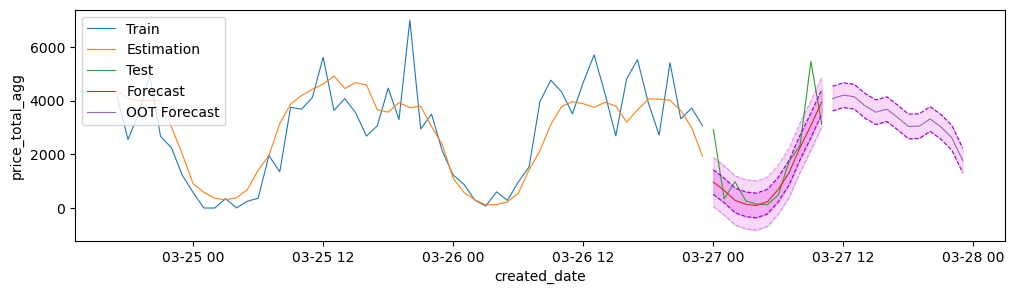

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 17.1556 - val_loss: 17.0208
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 13.5978 - val_loss: 11.2742
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 6.6528 - val_loss: 4.9951
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 4.9883 - val_loss: 4.7821
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 4.8723 - val_loss: 4.7871
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 4.7890 - val_loss: 4.6701
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 4.7611 - val_loss: 4.5824
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 4.6587 - val_loss: 4.5898
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 4.6541 - val_loss: 4.5824
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 4.6294 - val_loss: 4.5684
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 4.7153 - val_loss: 4.5622
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 4.6942 - val_loss: 4.4575
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 4.5837 - val_loss: 4.4516
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 4.5473 - val_loss: 4.4

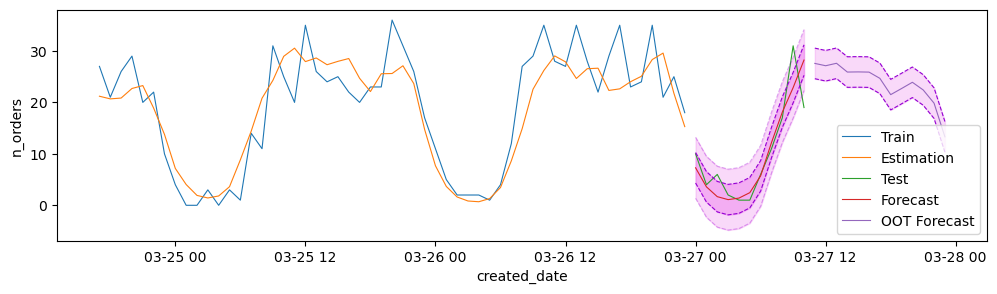

Processing account_id: 7db6eaca-fe22-41d7-bfb8-1fdde880feb8, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 23ms/step - loss: 287.8119 - val_loss: 245.4047
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 287.7557 - val_loss: 245.3549
Epoch 3/1000
60/60 - 0s - 6ms/step - loss: 287.6818 - val_loss: 245.2771
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 287.5419 - val_loss: 245.1614
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 287.3059 - val_loss: 245.0006
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 286.9435 - val_loss: 244.7893
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 286.5369 - val_loss: 244.5344
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 286.1301 - val_loss: 244.2340
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 285.7623 - val_loss: 243.8867
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 285.2825 - val_loss: 243.4666
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 284.7983 - val_loss: 243.0034
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 284.2572 - val_loss: 242.4840
Ep

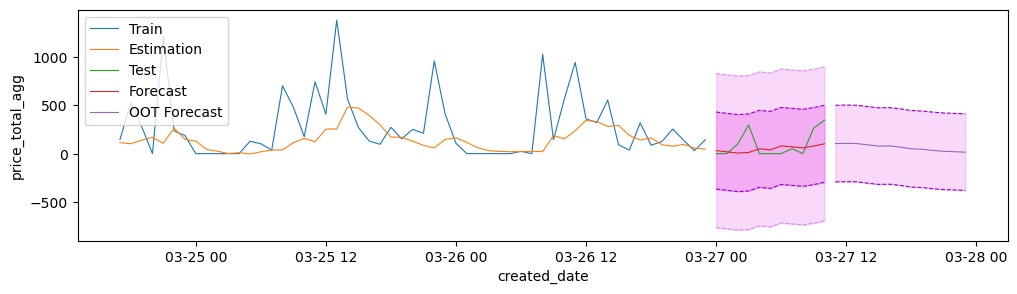

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 1.2990 - val_loss: 2.1039
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.1634 - val_loss: 1.8375
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.0590 - val_loss: 1.6950
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.9962 - val_loss: 1.5896
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.9555 - val_loss: 1.5653
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.9427 - val_loss: 1.5081
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 0.9407 - val_loss: 1.5149
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 0.9289 - val_loss: 1.4563
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 0.9134 - val_loss: 1.4524
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 0.9065 - val_loss: 1.4466
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 0.9293 - val_loss: 1.4241
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 0.9185 - val_loss: 1.4055
Epoch 13/1000
60/60 - 0s - 2ms/step - loss: 0.9005 - val_loss: 1.4104
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 0.8897 - val_loss: 1.3696


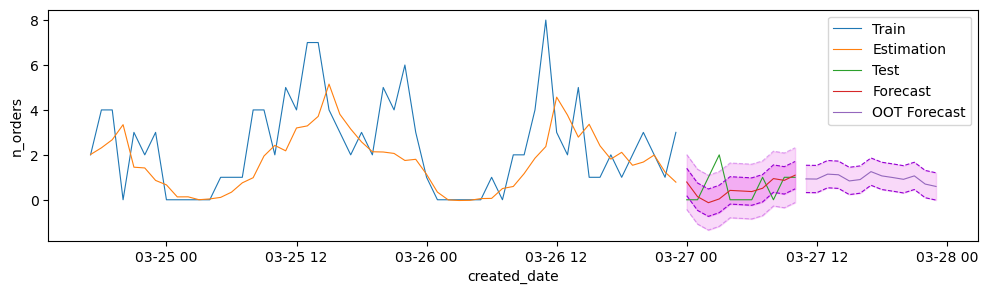

Processing account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 34637.7422 - val_loss: 30492.9102
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 34633.7070 - val_loss: 30486.0742
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 34622.5273 - val_loss: 30471.3359
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 34602.9805 - val_loss: 30448.2168
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 34574.4297 - val_loss: 30416.8027
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 34537.5664 - val_loss: 30376.7773
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 34490.3555 - val_loss: 30328.1191
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 34436.9883 - val_loss: 30272.4258
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 34374.2695 - val_loss: 30209.6543
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 34306.5312 - val_loss: 30140.4180
Epoch 11/1000
60/60 - 0s - 5ms/step - loss: 34231.5977 - val_loss: 30064.3574
Epoch 12/1000
60/60 - 0s - 1ms/s

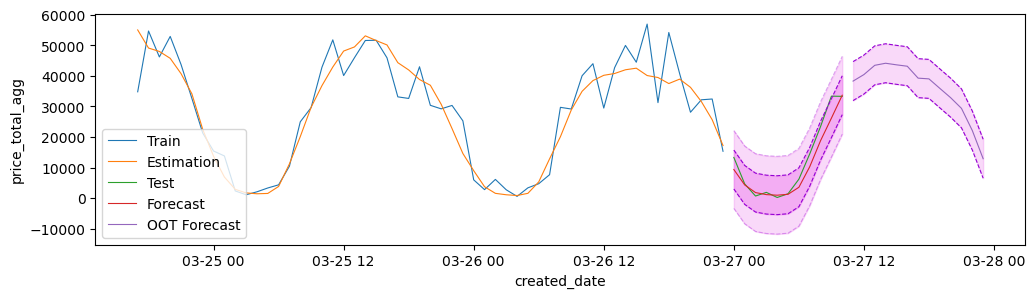

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 110.3484 - val_loss: 93.3174
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 105.9699 - val_loss: 86.9447
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 96.0470 - val_loss: 75.0966
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 80.1137 - val_loss: 57.2722
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 58.9491 - val_loss: 33.8672
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 36.7799 - val_loss: 15.9187
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 29.3391 - val_loss: 14.8315
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 28.5603 - val_loss: 14.3519
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 28.3825 - val_loss: 14.1641
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 28.1624 - val_loss: 13.8109
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 28.0609 - val_loss: 13.6355
Epoch 12/1000
60/60 - 0s - 1ms/step - loss: 27.4459 - val_loss: 13.5267
Epoch 13/1000
60/60 - 0s - 1ms/step - loss: 27.8622 - val_loss: 13.4449
Epoch 14/1000
60/60 - 0s - 1ms/step - loss

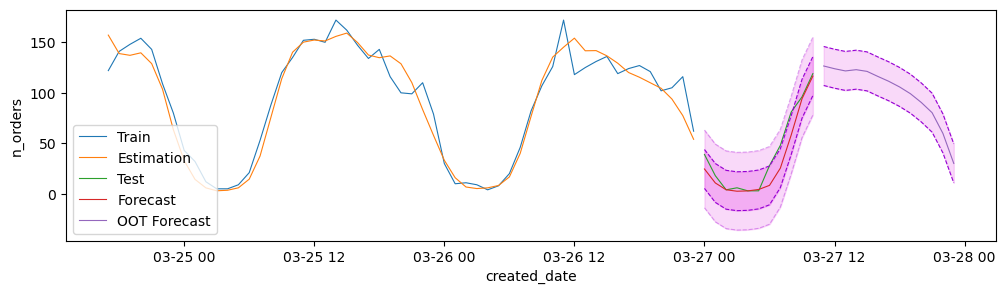

Processing account_id: 173e2b27-8bc6-44d1-b581-a1913d6b1894, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 6369.0015 - val_loss: 5040.0762
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 6366.1377 - val_loss: 5036.2710
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 6357.7788 - val_loss: 5027.3906
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 6342.6025 - val_loss: 5013.1318
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 6320.7749 - val_loss: 4993.8408
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 6292.7305 - val_loss: 4969.6016
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 6257.9829 - val_loss: 4940.4043
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 6219.1157 - val_loss: 4907.0625
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 6173.6216 - val_loss: 4869.5396
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 6121.7803 - val_loss: 4827.5195
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 6064.9663 - val_loss: 4780.5439
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 6006.6958 

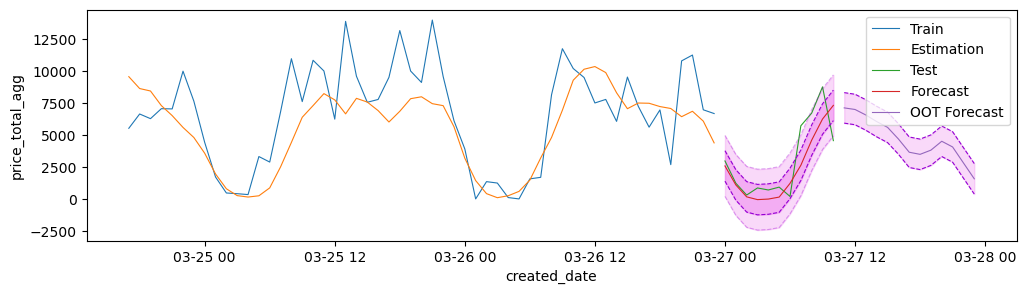

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 22ms/step - loss: 15.9865 - val_loss: 12.7611
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 14.0100 - val_loss: 10.2121
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 9.1834 - val_loss: 5.2238
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 5.5815 - val_loss: 4.3971
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 5.4513 - val_loss: 4.3302
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 5.2587 - val_loss: 4.2932
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 5.1600 - val_loss: 4.2320
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 4.9860 - val_loss: 4.1852
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 4.8549 - val_loss: 4.1467
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 4.9297 - val_loss: 4.0950
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 4.8480 - val_loss: 4.0920
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 4.9177 - val_loss: 4.0652
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 4.8898 - val_loss: 4.0322
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 4.8051 - val_loss: 4.0

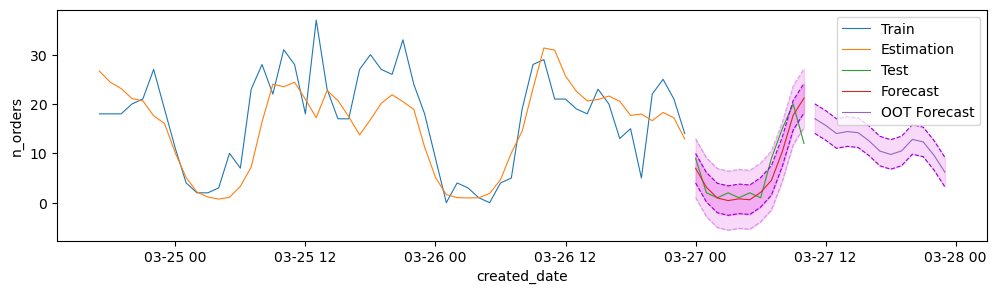

Processing account_id: 60c8f748-e29d-4fce-9e66-584117ca2baf, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 6656.5679 - val_loss: 8843.7354
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 6653.8008 - val_loss: 8837.1221
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 6645.6074 - val_loss: 8822.1953
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 6630.2808 - val_loss: 8798.5293
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 6607.0513 - val_loss: 8765.8525
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 6576.3213 - val_loss: 8725.2100
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 6539.0132 - val_loss: 8676.8262
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 6494.0459 - val_loss: 8620.7959
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 6443.9541 - val_loss: 8557.9688
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 6389.8647 - val_loss: 8488.2725
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 6326.0073 - val_loss: 8411.3789
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 6256.1367 

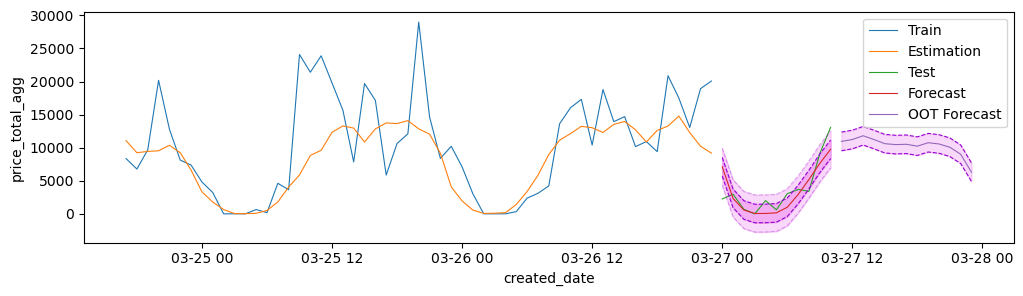

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 14.7229 - val_loss: 16.8984
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 11.9549 - val_loss: 10.9005
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 6.5694 - val_loss: 5.5635
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 5.2562 - val_loss: 5.4466
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 5.2051 - val_loss: 5.4367
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 5.1826 - val_loss: 5.4326
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 5.1198 - val_loss: 5.3919
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 5.0527 - val_loss: 5.4150
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 5.0838 - val_loss: 5.3464
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 5.0107 - val_loss: 5.3475
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 5.0277 - val_loss: 5.3255
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 5.0716 - val_loss: 5.2852
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 5.0687 - val_loss: 5.2816
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 4.8568 - val_loss: 5.2

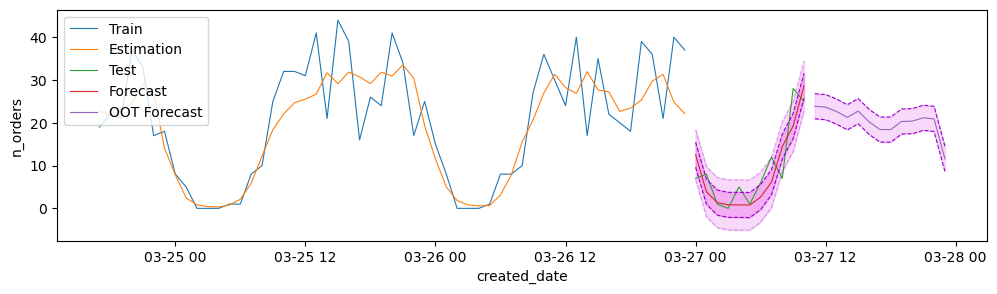

Processing account_id: 60ca8452-5b14-481f-a637-8756f527aee8, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 275.6778 - val_loss: 6.5109e-05
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 275.6258 - val_loss: 6.0620e-04
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 275.5452 - val_loss: 1.1936e-04
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 275.3547 - val_loss: 1.6417e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Epoch 1/1000
61/61 - 1s - 12ms/step - loss: 272.5450 - val_loss: 9.6245e-04
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 272.4925 - val_loss: 0.0016
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 272.3945 - val_loss: 2.1135e-04
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 272.2413 - val_loss: 1.9077e-04
Epoch 5/1000
61/61 - 0s - 3ms/step - loss: 271.9406 - val_loss: 5.6740e-05
Epoch 6/1000
61/61 - 0s - 2ms/step - loss: 271.6051 - val_loss: 3.8101e-06
Epoch 7/1000
61/61 - 0s - 2ms/step - loss: 271.1925 - val

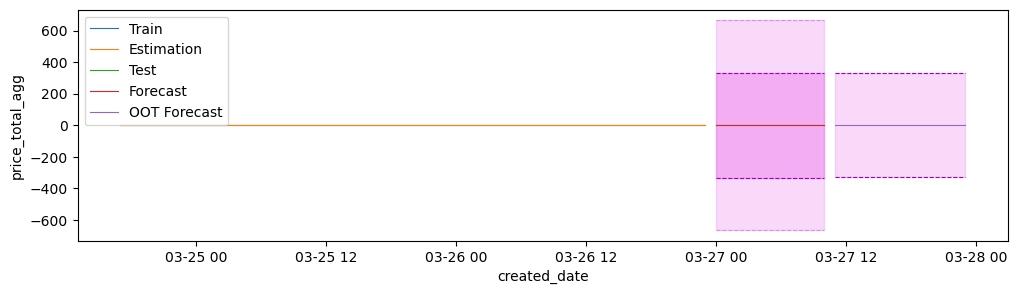

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 1.3959 - val_loss: 1.2217e-04
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1.3582 - val_loss: 1.1524e-04
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.3339 - val_loss: 7.4371e-05
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.3077 - val_loss: 1.7070e-04
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.2499 - val_loss: 2.1075e-05
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.2089 - val_loss: 2.2587e-05
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.1653 - val_loss: 4.1840e-04
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.1241 - val_loss: 2.0246e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 1/1000
61/61 - 1s - 15ms/step - loss: 1.3879 - val_loss: 3.5640e-04
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 1.3473 - val_loss: 2.7997e-04
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 1.3256 - val_loss: 8.7520e-05
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 1.2972 - val_loss: 2.3666e-05
Epoch 5/1000
61/6

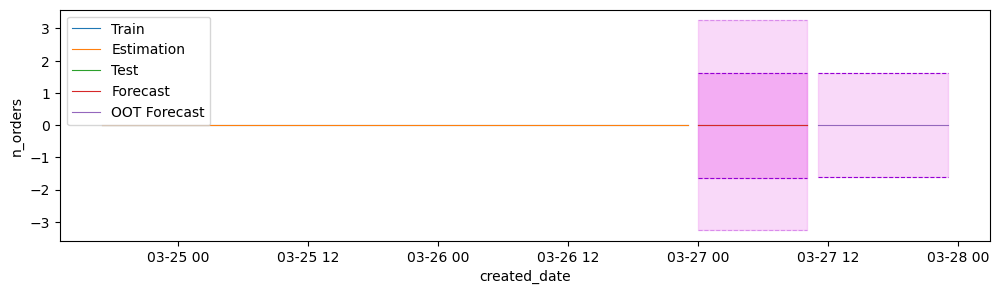

Processing account_id: 3dc15e4b-b60d-4c49-aae8-97cf9664af51, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 36.3395 - val_loss: 49.5078
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 36.3264 - val_loss: 49.4977
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 36.3214 - val_loss: 49.4945
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 36.3114 - val_loss: 49.4846
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 36.2982 - val_loss: 49.4733
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 36.2890 - val_loss: 49.4565
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 36.2681 - val_loss: 49.4338
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 36.2489 - val_loss: 49.4037
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 36.2307 - val_loss: 49.3711
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 36.2269 - val_loss: 49.3454
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 36.1956 - val_loss: 49.3300
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 36.1765 - val_loss: 49.3079
Epoch 13/1000
60/60 - 0s -

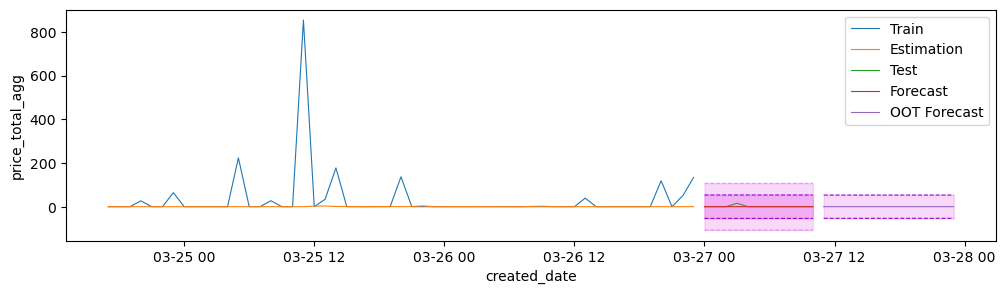

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 17ms/step - loss: 0.4359 - val_loss: 0.6389
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.4280 - val_loss: 0.6328
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 0.4231 - val_loss: 0.6335
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 0.4206 - val_loss: 0.6294
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.4200 - val_loss: 0.6260
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.4205 - val_loss: 0.6267
Epoch 7/1000
60/60 - 0s - 5ms/step - loss: 0.4185 - val_loss: 0.6239
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 0.4167 - val_loss: 0.6209
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 0.4161 - val_loss: 0.6267
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 0.4131 - val_loss: 0.6226
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 0.4151 - val_loss: 0.6266
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Epoch 1/1000
61/61 - 1s - 11ms/step - loss: 0.4281 - val_loss: 0.6275
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 0.4232 - val_loss: 0

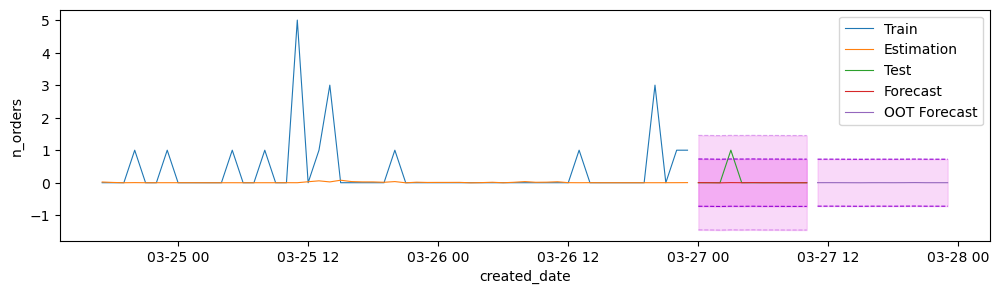

Processing account_id: 9d1296ca-9e4f-4840-b7b5-e12172acab78, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 246.7852 - val_loss: 224.7172
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 246.6566 - val_loss: 224.7336
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 246.4046 - val_loss: 224.7684
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 245.8074 - val_loss: 224.8147
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 1/1000
61/61 - 1s - 17ms/step - loss: 247.7071 - val_loss: 189.4383
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 247.5795 - val_loss: 189.4519
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 247.3213 - val_loss: 189.4792
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 246.7061 - val_loss: 189.5186
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1

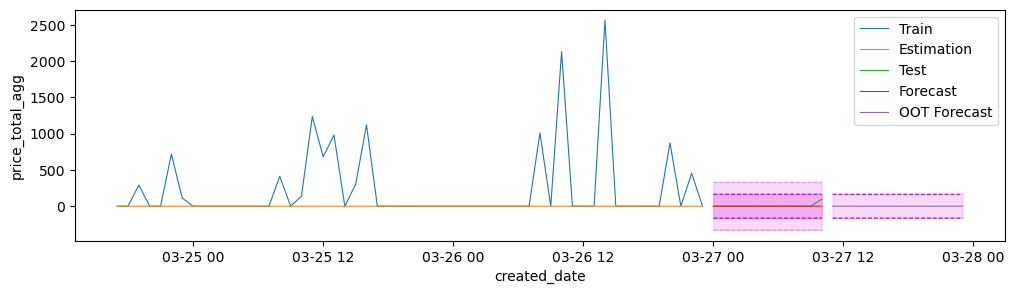

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 1.0115 - val_loss: 0.4402
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 0.8118 - val_loss: 0.4403
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.7767 - val_loss: 0.4391
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 0.7428 - val_loss: 0.4393
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.7145 - val_loss: 0.4387
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 0.7577 - val_loss: 0.4388
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 0.6880 - val_loss: 0.4381
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 0.7262 - val_loss: 0.4383
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 0.6613 - val_loss: 0.4379
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 0.6862 - val_loss: 0.4376
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 0.6542 - val_loss: 0.4378
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 0.6576 - val_loss: 0.4374
Epoch 13/1000
60/60 - 0s - 2ms/step - loss: 0.6824 - val_loss: 0.4378
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 0.7104 - val_loss: 0.4373


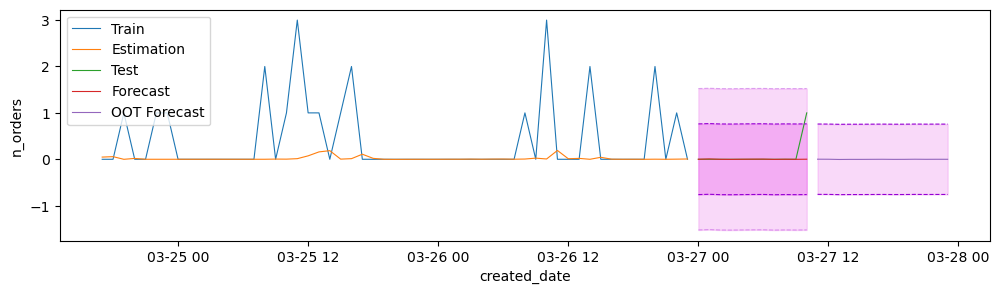

Processing account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 45589.5508 - val_loss: 60534.7227
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 45586.1172 - val_loss: 60527.3867
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 45576.8281 - val_loss: 60511.8594
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 45560.7148 - val_loss: 60488.7188
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 45537.7891 - val_loss: 60457.9375
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 45508.6484 - val_loss: 60419.6094
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 45472.4727 - val_loss: 60373.4727
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 45429.6094 - val_loss: 60319.6797
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 45379.7773 - val_loss: 60259.3867
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 45324.8828 - val_loss: 60192.7734
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 45267.8477 - val_loss: 60121.6055
Epoch 12/1000
60/60 - 0s - 2ms/s

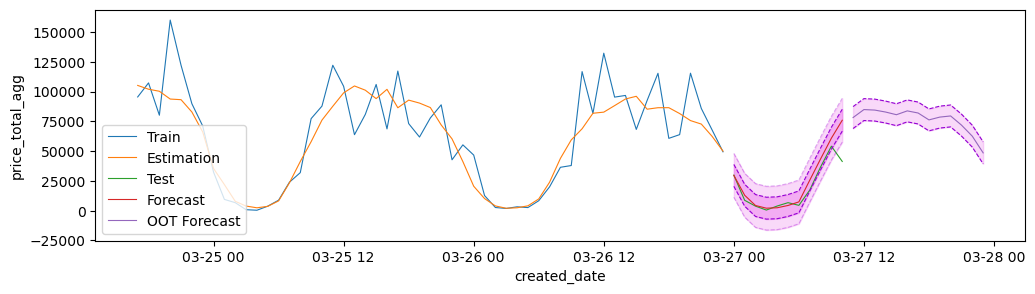

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 71.2441 - val_loss: 77.0351
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 68.1076 - val_loss: 71.1371
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 60.3239 - val_loss: 59.1040
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 47.4485 - val_loss: 41.0732
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 30.5075 - val_loss: 20.6000
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 18.9918 - val_loss: 12.6912
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 17.4396 - val_loss: 12.3362
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 16.8536 - val_loss: 12.0967
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 16.6727 - val_loss: 11.9371
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 16.3005 - val_loss: 11.7793
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 16.2713 - val_loss: 11.6337
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 16.1093 - val_loss: 11.6293
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 15.8204 - val_loss: 11.5414
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 

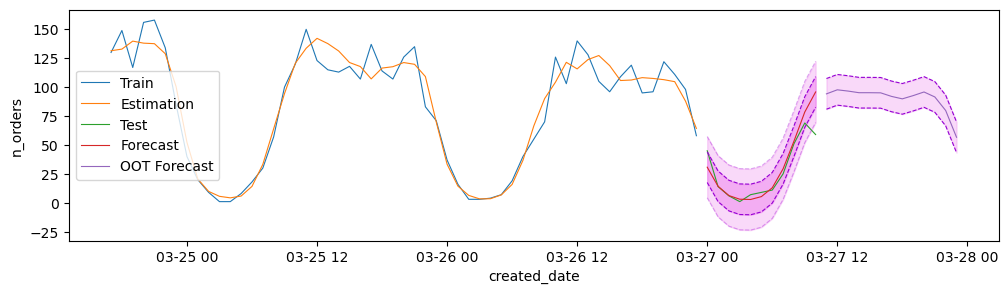

Processing account_id: 6276b87c-ebb2-11ed-a05b-0242ac120003, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 22ms/step - loss: 495.7901 - val_loss: 588.1124
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 494.2576 - val_loss: 585.3566
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 489.4450 - val_loss: 577.9479
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 479.3931 - val_loss: 564.9741
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 464.3728 - val_loss: 546.7155
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 444.6460 - val_loss: 523.5223
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 421.7507 - val_loss: 497.2784
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 395.6736 - val_loss: 468.9061
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 371.7542 - val_loss: 440.6197
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 349.0232 - val_loss: 414.6469
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 329.9380 - val_loss: 390.8944
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 312.8459 - val_loss: 370.4754
Ep

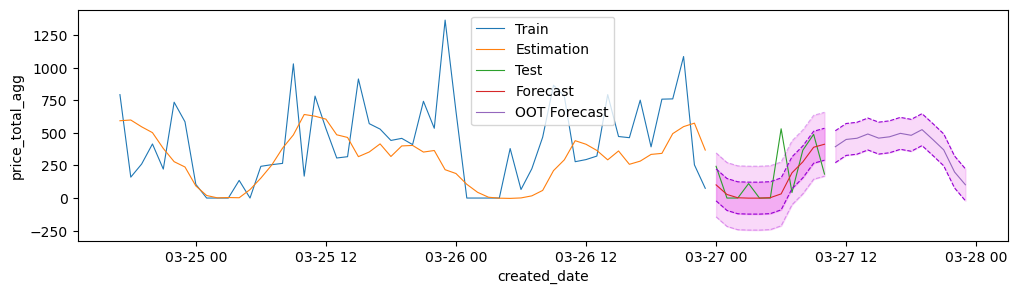

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 33ms/step - loss: 3.7426 - val_loss: 3.5302
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 2.4859 - val_loss: 1.9408
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.9400 - val_loss: 1.7946
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.8537 - val_loss: 1.7679
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.8680 - val_loss: 1.7763
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.8795 - val_loss: 1.7731
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 1.8451 - val_loss: 1.7564
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 1.8200 - val_loss: 1.7474
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 1.7991 - val_loss: 1.7574
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.8011 - val_loss: 1.7335
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1.8057 - val_loss: 1.7346
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1.7608 - val_loss: 1.7231
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 1.7952 - val_loss: 1.7207
Epoch 14/1000
60/60 - 0s - 4ms/step - loss: 1.7712 - val_loss: 1.7162


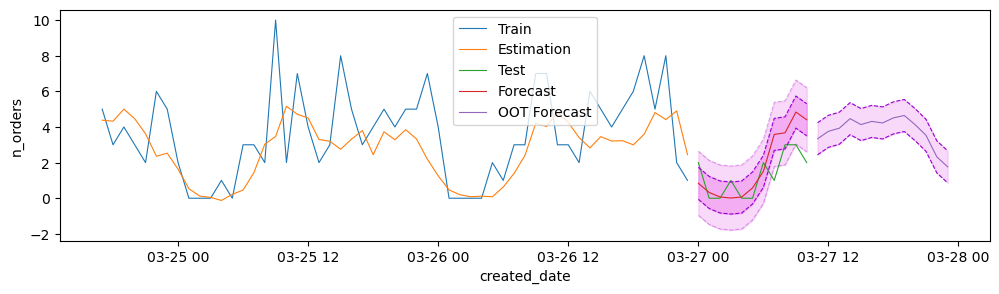

Processing account_id: 6cd2fa8a-5bac-4cc0-b4df-bd2c7d29e71b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 3s - 43ms/step - loss: 144.2452 - val_loss: 88.7713
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 144.1713 - val_loss: 88.7690
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 144.0580 - val_loss: 88.7510
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 143.7492 - val_loss: 88.6952
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 143.1425 - val_loss: 88.5795
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 142.2183 - val_loss: 88.3921
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 140.8371 - val_loss: 88.1188
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 139.0822 - val_loss: 87.7882
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 137.2985 - val_loss: 87.4363
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 135.8873 - val_loss: 87.0964
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 134.7300 - val_loss: 86.9200
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 133.3419 - val_loss: 86.8836
Epoch 13/1000


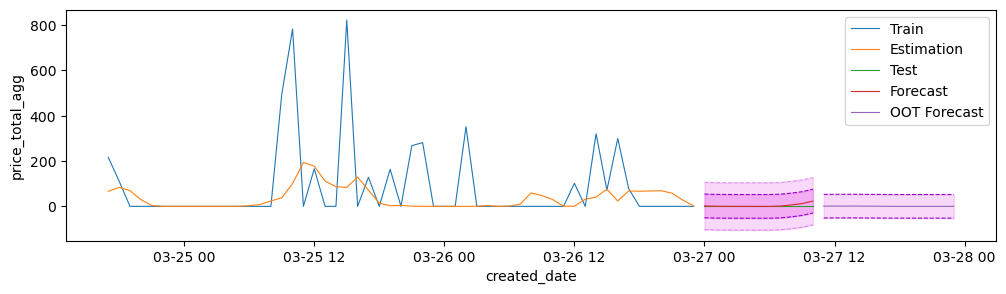

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 0.6671 - val_loss: 0.4555
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.6237 - val_loss: 0.4529
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.6120 - val_loss: 0.4538
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.6092 - val_loss: 0.4552
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.6058 - val_loss: 0.4546
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 1/1000
61/61 - 1s - 14ms/step - loss: 0.6763 - val_loss: 0.4019
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.6254 - val_loss: 0.4016
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.6118 - val_loss: 0.4046
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.6038 - val_loss: 0.4102
Epoch 5/1000
61/61 - 0s - 2ms/step - loss: 0.6012 - val_loss: 0.4142
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━

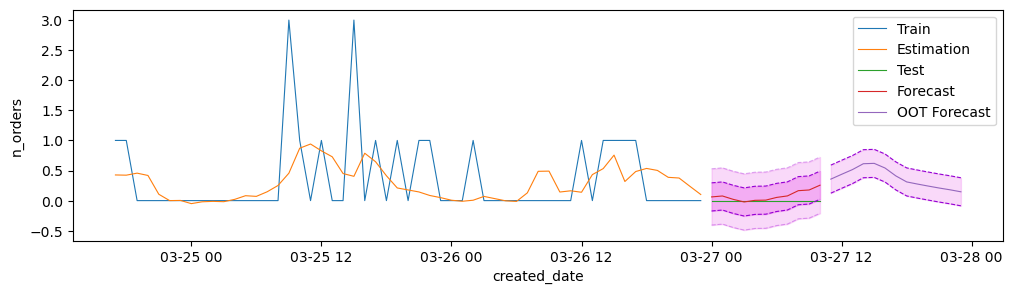

Processing account_id: 92f116fe-5818-41db-9eb5-87445ad3818e, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 654.0590 - val_loss: 675.8105
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 653.0908 - val_loss: 673.6979
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 649.8737 - val_loss: 667.6911
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 643.2082 - val_loss: 656.9810
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 632.5644 - val_loss: 642.1476
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 618.6663 - val_loss: 624.0022
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 602.1735 - val_loss: 604.4636
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 583.5998 - val_loss: 584.4821
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 566.0862 - val_loss: 565.3736
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 548.9200 - val_loss: 550.0816
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 533.6888 - val_loss: 536.2772
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 519.9850 - val_loss: 524.0487
Ep

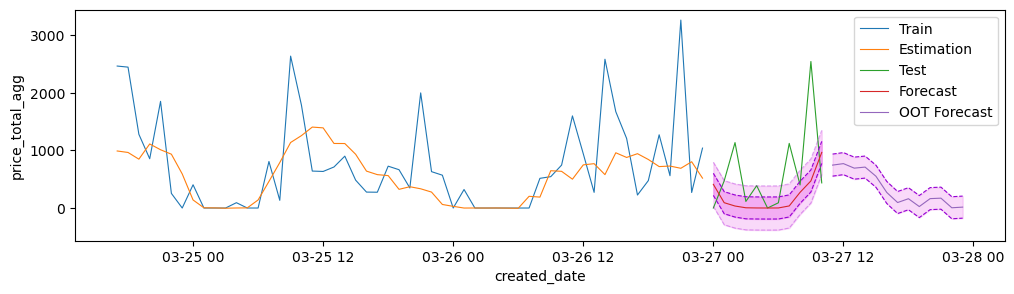

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 1.8507 - val_loss: 1.5460
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.3497 - val_loss: 1.2505
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.2495 - val_loss: 1.2159
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 1.2392 - val_loss: 1.2142
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1.2251 - val_loss: 1.2105
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1.2203 - val_loss: 1.2078
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 1.1909 - val_loss: 1.2042
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1.1962 - val_loss: 1.2001
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1.1813 - val_loss: 1.1948
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.1742 - val_loss: 1.1907
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1.1535 - val_loss: 1.1928
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1.1642 - val_loss: 1.1801
Epoch 13/1000
60/60 - 0s - 2ms/step - loss: 1.1542 - val_loss: 1.1794
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 1.1313 - val_loss: 1.1786


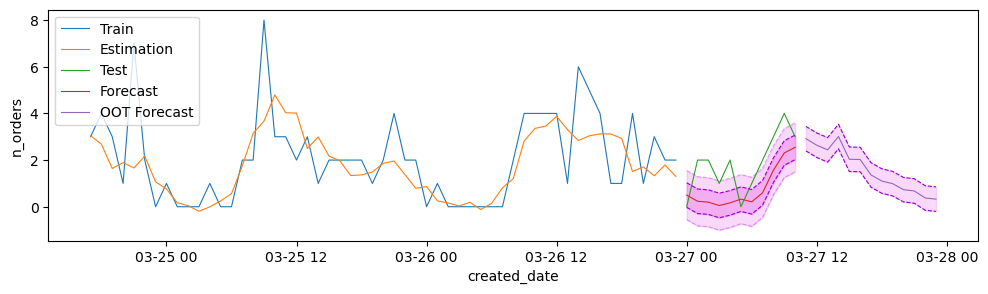

Processing account_id: f9129295-bb08-4330-b60c-9f0beadda521, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 528770.6250 - val_loss: 511753.0938
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 528765.1875 - val_loss: 511743.6875
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 528750.6875 - val_loss: 511724.6562
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 528726.6250 - val_loss: 511697.3750
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 528695.8125 - val_loss: 511662.2812
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 528655.2500 - val_loss: 511618.9688
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 528607.4375 - val_loss: 511568.0000
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 528551.7500 - val_loss: 511509.1875
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 528488.6250 - val_loss: 511442.3750
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 528415.4375 - val_loss: 511367.2812
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 528334.5625 - val_loss: 511284.5938
Epoch 12/1

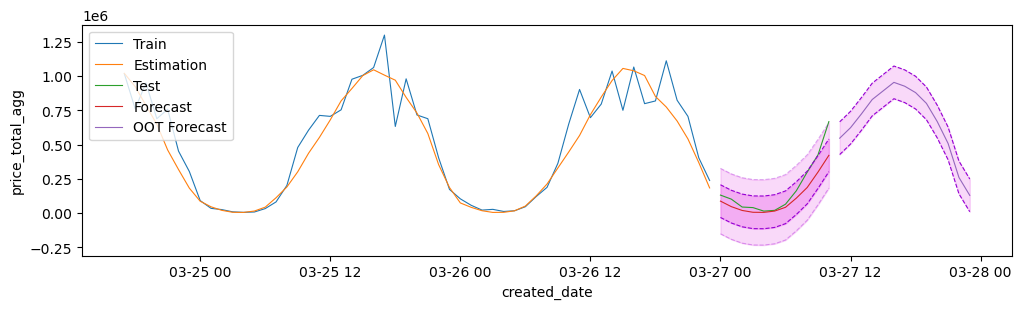

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 192.9623 - val_loss: 180.4077
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 187.8237 - val_loss: 172.5312
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 176.6201 - val_loss: 158.8578
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 159.2119 - val_loss: 139.3186
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 137.2144 - val_loss: 115.7794
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 111.0841 - val_loss: 89.6982
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 82.6190 - val_loss: 61.2581
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 59.8016 - val_loss: 37.7208
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 47.4741 - val_loss: 32.3554
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 44.7227 - val_loss: 31.2885
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 44.7599 - val_loss: 30.5632
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 44.5980 - val_loss: 30.1726
Epoch 13/1000
60/60 - 0s - 6ms/step - loss: 44.3312 - val_loss: 29.6878
Epoch 14/1000
60/60 - 0s - 3ms/st

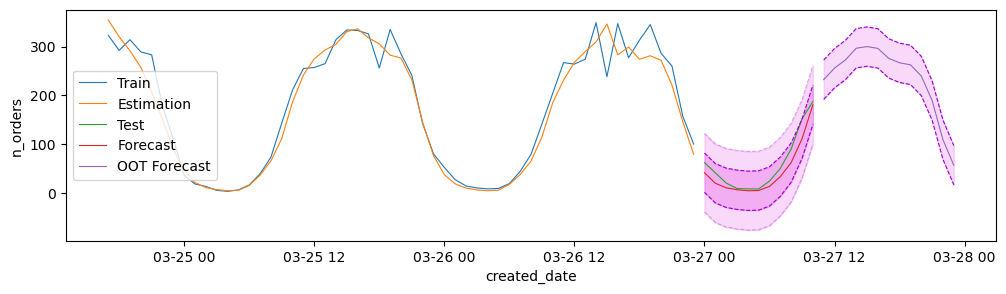

Processing account_id: d639773a-df2c-421e-ac87-6918a754572f, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 447.6492 - val_loss: 765.9405
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 447.6243 - val_loss: 765.9061
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 447.6054 - val_loss: 765.8660
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 447.5607 - val_loss: 765.7816
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 447.4974 - val_loss: 765.6572
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 447.3925 - val_loss: 765.4717
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 447.2797 - val_loss: 765.2935
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 447.1521 - val_loss: 764.9593
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 446.9221 - val_loss: 764.7063
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 446.6520 - val_loss: 764.1749
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 446.4288 - val_loss: 763.8558
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 446.1605 - val_loss: 763.2654
Ep

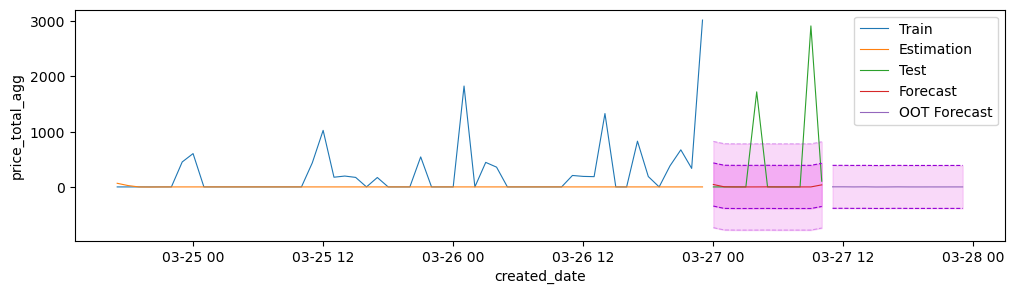

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 18ms/step - loss: 2.5305 - val_loss: 1.2165
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 2.5019 - val_loss: 1.2164
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.4806 - val_loss: 1.2137
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 2.4515 - val_loss: 1.2128
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 2.4038 - val_loss: 1.2097
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 2.3326 - val_loss: 1.2075
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 2.2697 - val_loss: 1.2036
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 2.1774 - val_loss: 1.2008
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 2.1544 - val_loss: 1.1958
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 2.1289 - val_loss: 1.1952
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 2.0909 - val_loss: 1.1865
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 2.0415 - val_loss: 1.1860
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 1.9387 - val_loss: 1.1804
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 1.8966 - val_loss: 1.1797


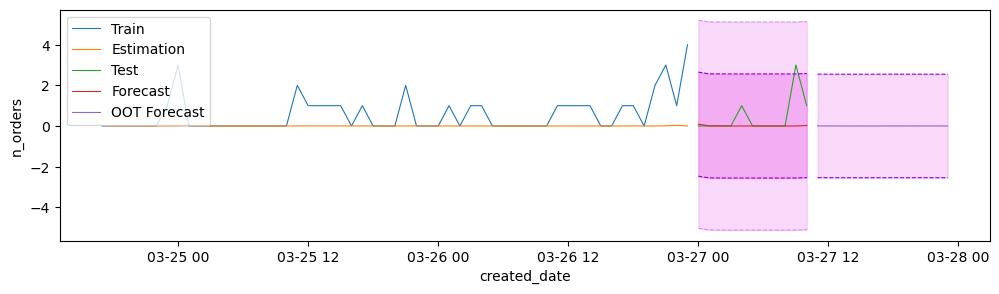

Processing account_id: 50409b57-b000-43d5-9358-44c3081c4132, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 21ms/step - loss: 284.4170 - val_loss: 467.9224
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 284.3456 - val_loss: 467.6552
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 284.2243 - val_loss: 467.1102
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 283.9565 - val_loss: 466.0259
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 283.5145 - val_loss: 464.2514
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 282.8230 - val_loss: 461.7090
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 281.9643 - val_loss: 458.4830
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 280.8525 - val_loss: 454.5810
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 279.4882 - val_loss: 450.0189
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 277.9325 - val_loss: 445.0191
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 276.6956 - val_loss: 440.4878
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 275.2518 - val_loss: 435.8967
Ep

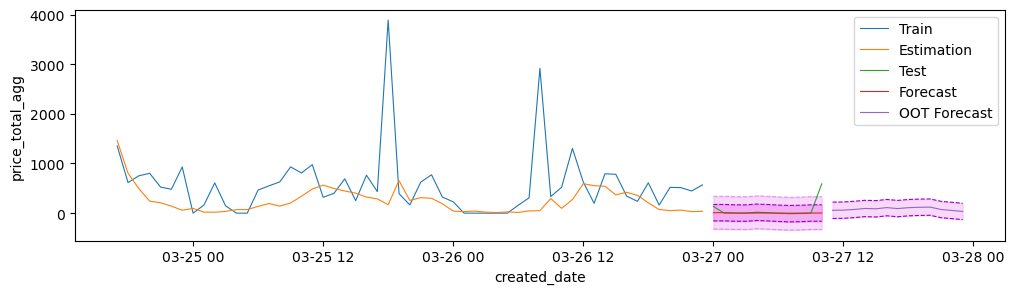

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 1.1741 - val_loss: 1.6811
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.1190 - val_loss: 1.5430
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.0462 - val_loss: 1.3665
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.9858 - val_loss: 1.3126
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.9665 - val_loss: 1.2848
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.9386 - val_loss: 1.2363
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 0.9319 - val_loss: 1.2421
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 0.9204 - val_loss: 1.2073
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 0.9282 - val_loss: 1.2182
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 0.9142 - val_loss: 1.1905
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 0.9121 - val_loss: 1.1704
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 0.9064 - val_loss: 1.1632
Epoch 13/1000
60/60 - 0s - 2ms/step - loss: 0.9062 - val_loss: 1.1827
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 0.9008 - val_loss: 1.1394


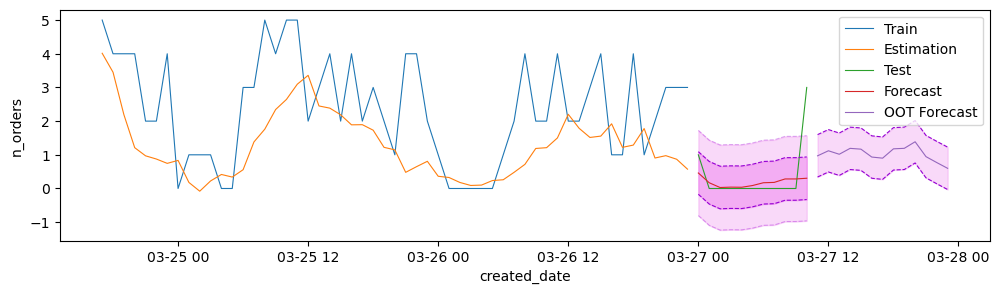

Processing account_id: 457bce7b-9300-4c10-9a97-070b3c0d081d, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 27ms/step - loss: 1214.6650 - val_loss: 1753.0157
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 1214.6412 - val_loss: 1752.9545
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1214.6006 - val_loss: 1752.8319
Epoch 4/1000
60/60 - 0s - 6ms/step - loss: 1214.5359 - val_loss: 1752.5869
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 1214.3962 - val_loss: 1752.1279
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1214.2091 - val_loss: 1751.4384
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1213.8853 - val_loss: 1750.4207
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1213.3995 - val_loss: 1749.0197
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1212.7983 - val_loss: 1747.2673
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 1211.9659 - val_loss: 1745.1417
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1211.1416 - val_loss: 1742.7429
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 1210.0780 

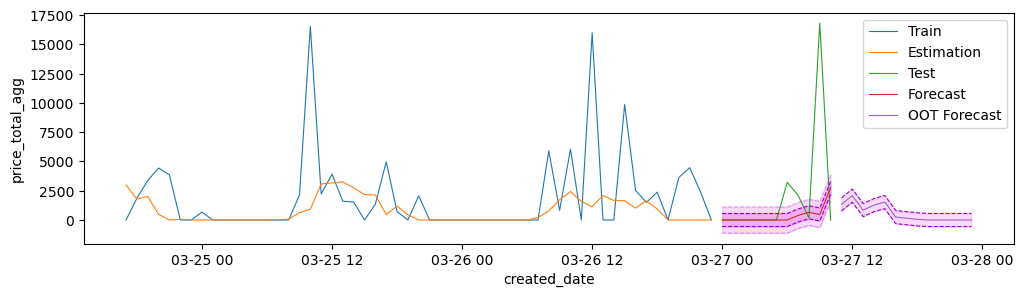

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 26ms/step - loss: 0.6030 - val_loss: 0.7655
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 0.5670 - val_loss: 0.7056
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.5587 - val_loss: 0.6995
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.5508 - val_loss: 0.6922
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 0.5418 - val_loss: 0.6929
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 0.5388 - val_loss: 0.6911
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.5388 - val_loss: 0.6931
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.5357 - val_loss: 0.6886
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 0.5351 - val_loss: 0.6885
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 0.5313 - val_loss: 0.6904
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 0.5300 - val_loss: 0.6870
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 0.5266 - val_loss: 0.6845
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 0.5259 - val_loss: 0.6862
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 0.5269 - val_loss: 0.6906


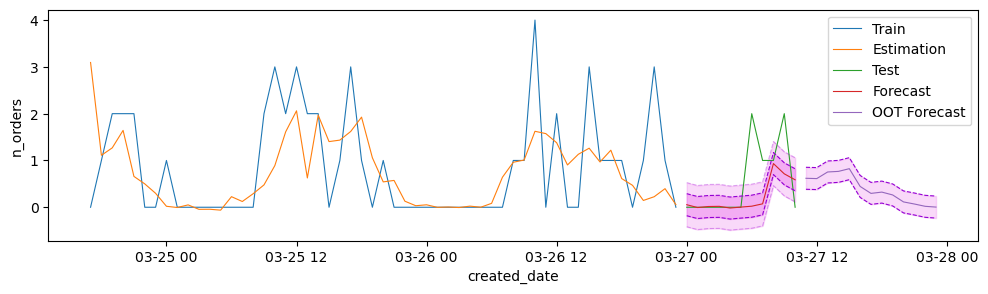

Processing account_id: 775dcad4-0733-4c22-8dbd-cd3ce344e891, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 1304.4919 - val_loss: 764.0336
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1302.9773 - val_loss: 762.7408
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 1298.3774 - val_loss: 759.5120
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1289.6033 - val_loss: 753.8143
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1275.9720 - val_loss: 745.3298
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1258.6322 - val_loss: 733.8925
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1236.3049 - val_loss: 719.8626
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1210.6847 - val_loss: 703.2997
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1180.8641 - val_loss: 684.3411
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1146.5417 - val_loss: 663.5152
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1112.2273 - val_loss: 642.5184
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1074.4637 - val_loss:

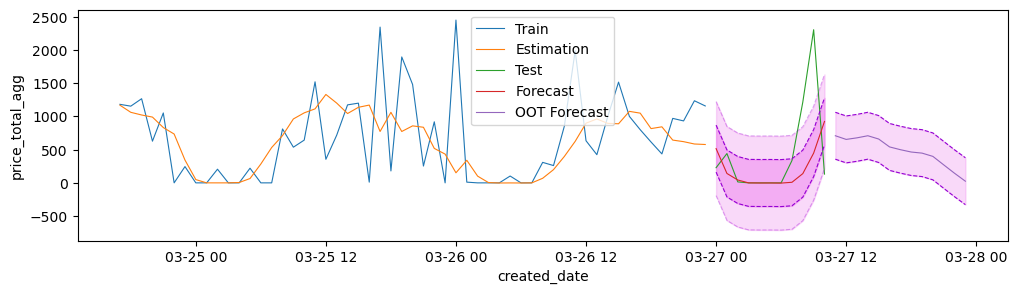

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 3.6288 - val_loss: 2.0327
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 2.4756 - val_loss: 1.4512
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 2.0660 - val_loss: 1.4043
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 2.0111 - val_loss: 1.4040
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 1.9594 - val_loss: 1.4053
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 1.9375 - val_loss: 1.3961
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 1.9356 - val_loss: 1.3857
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 1.8528 - val_loss: 1.3756
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1.8873 - val_loss: 1.3763
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 1.8783 - val_loss: 1.3805
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 1.8389 - val_loss: 1.3772
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch 1/1000
61/61 - 1s - 10ms/step - loss: 3.6413 - val_loss: 1.8101
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 2.4714 - val_loss: 1

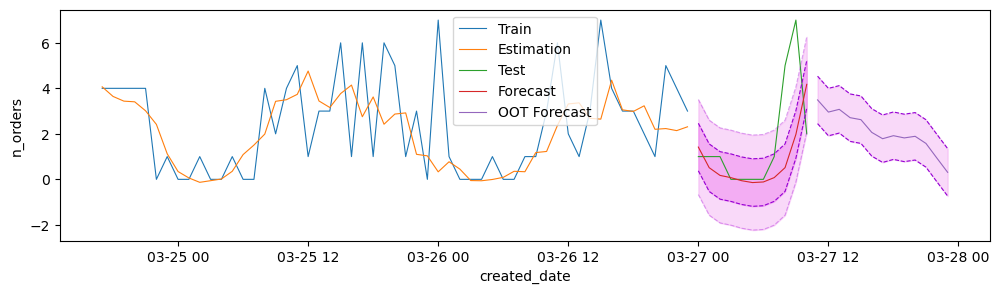

Processing account_id: e2de40dd-743b-4105-9077-3f343fea980d, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 2971.2305 - val_loss: 3025.2781
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 2970.0552 - val_loss: 3023.1641
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2966.2712 - val_loss: 3017.3430
Epoch 4/1000
60/60 - 0s - 6ms/step - loss: 2957.9319 - val_loss: 3006.3391
Epoch 5/1000
60/60 - 0s - 6ms/step - loss: 2943.8489 - val_loss: 2989.6157
Epoch 6/1000
60/60 - 0s - 7ms/step - loss: 2924.0776 - val_loss: 2967.2441
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 2899.1936 - val_loss: 2939.5833
Epoch 8/1000
60/60 - 0s - 6ms/step - loss: 2867.7769 - val_loss: 2906.4741
Epoch 9/1000
60/60 - 0s - 5ms/step - loss: 2833.6272 - val_loss: 2868.6326
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 2793.4653 - val_loss: 2826.0723
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 2747.9915 - val_loss: 2778.8428
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 2700.5972 

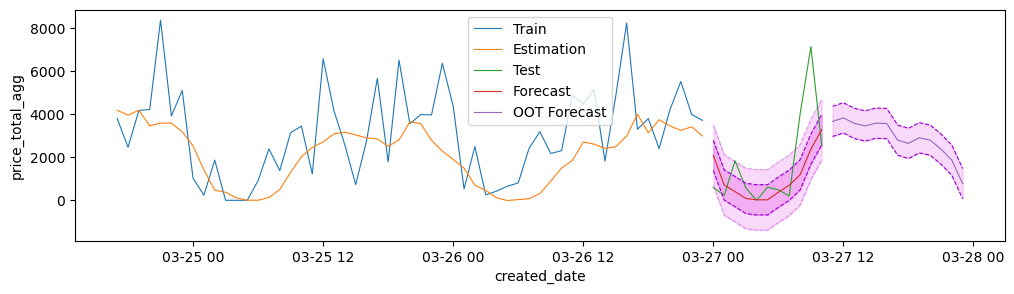

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 9.7298 - val_loss: 7.7225
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 8.6108 - val_loss: 6.1513
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 6.2973 - val_loss: 3.9582
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 4.5188 - val_loss: 3.4599
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 4.1519 - val_loss: 3.3939
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 4.1370 - val_loss: 3.3702
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 4.0938 - val_loss: 3.3268
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 4.0457 - val_loss: 3.3086
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 3.9560 - val_loss: 3.2918
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 4.0044 - val_loss: 3.2641
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 3.9778 - val_loss: 3.2627
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 3.8374 - val_loss: 3.2440
Epoch 13/1000
60/60 - 0s - 2ms/step - loss: 3.8815 - val_loss: 3.2386
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 3.8174 - val_loss: 3.2390


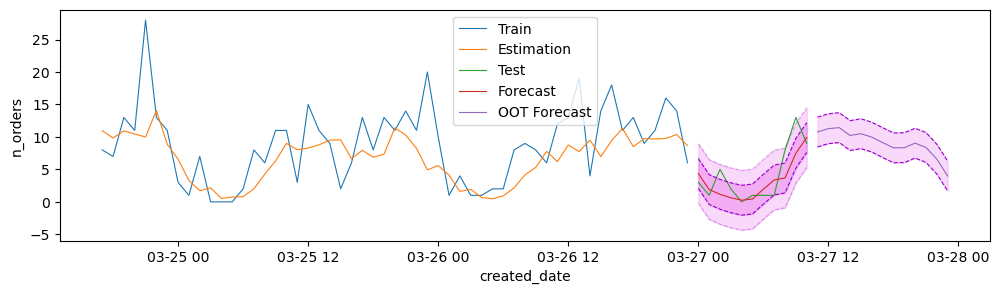

Processing account_id: c0cc925b-66c1-4b1c-b609-1bddc82ef4a4, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 31.8015 - val_loss: 0.0014
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 31.7875 - val_loss: 0.0040
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 31.7802 - val_loss: 3.3539e-04
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 31.7749 - val_loss: 6.2388e-04
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 31.7721 - val_loss: 3.6792e-05
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 31.7676 - val_loss: 7.5975e-04
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 31.7658 - val_loss: 5.1736e-04
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 31.7642 - val_loss: 1.9750e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch 1/1000
61/61 - 2s - 29ms/step - loss: 31.4387 - val_loss: 0.0037
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 31.4239 - val_loss: 0.0039
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 31.4144 - val_loss: 4.0445e-05
Epoch

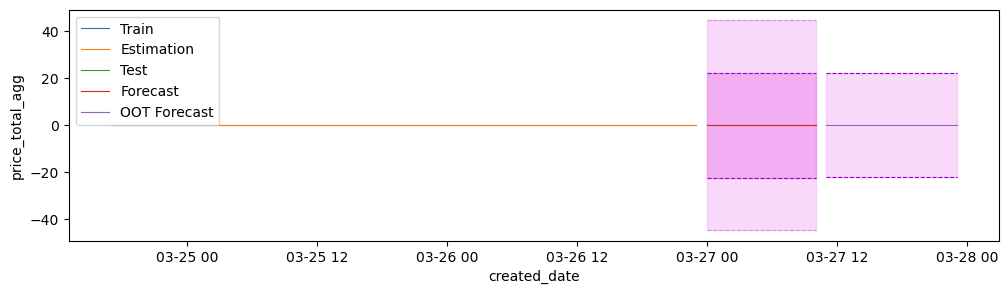

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 0.2730 - val_loss: 0.0016
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.2591 - val_loss: 0.0018
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 0.2519 - val_loss: 2.4924e-04
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.2459 - val_loss: 0.0014
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 0.2441 - val_loss: 0.0013
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.2404 - val_loss: 4.6279e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Epoch 1/1000
61/61 - 1s - 11ms/step - loss: 0.2669 - val_loss: 0.0027
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 0.2560 - val_loss: 9.8819e-05
Epoch 3/1000
61/61 - 0s - 1ms/step - loss: 0.2480 - val_loss: 6.0641e-04
Epoch 4/1000
61/61 - 0s - 1ms/step - loss: 0.2442 - val_loss: 0.0023
Epoch 5/1000
61/61 - 0s - 1ms/step - loss: 0.2402 - val_loss: 6.0010e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


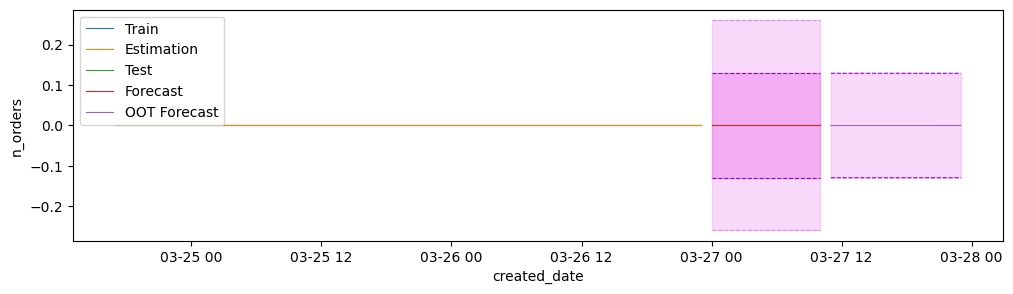

Processing account_id: 0ad2f65b-ee0e-4d50-93e2-84b76282325f, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 18ms/step - loss: 4503.8081 - val_loss: 6033.4497
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 4502.5552 - val_loss: 6029.9731
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 4498.2363 - val_loss: 6020.3120
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 4488.9033 - val_loss: 6003.3115
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 4473.9204 - val_loss: 5979.6104
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 4453.9160 - val_loss: 5950.0527
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 4428.8564 - val_loss: 5914.4351
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 4399.7236 - val_loss: 5873.3779
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 4366.6455 - val_loss: 5827.6289
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 4330.4238 - val_loss: 5777.1157
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 4290.1533 - val_loss: 5723.1606
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 4246.4019 

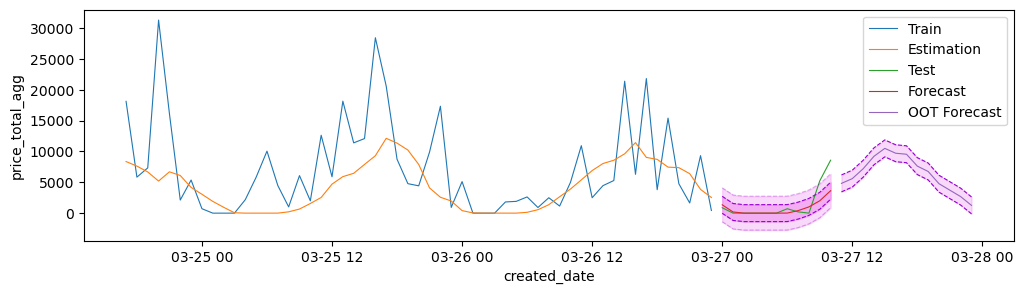

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 3.9037 - val_loss: 3.0426
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 2.7563 - val_loss: 1.8466
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 2.1168 - val_loss: 1.8617
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 2.0774 - val_loss: 1.8537
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 2.1050 - val_loss: 1.8748
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Epoch 1/1000
61/61 - 1s - 12ms/step - loss: 3.9545 - val_loss: 2.8384
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 2.7387 - val_loss: 1.8799
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 2.1076 - val_loss: 1.9195
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 2.0929 - val_loss: 1.9240
Epoch 5/1000
61/61 - 0s - 2ms/step - loss: 2.0950 - val_loss: 1.9165
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━

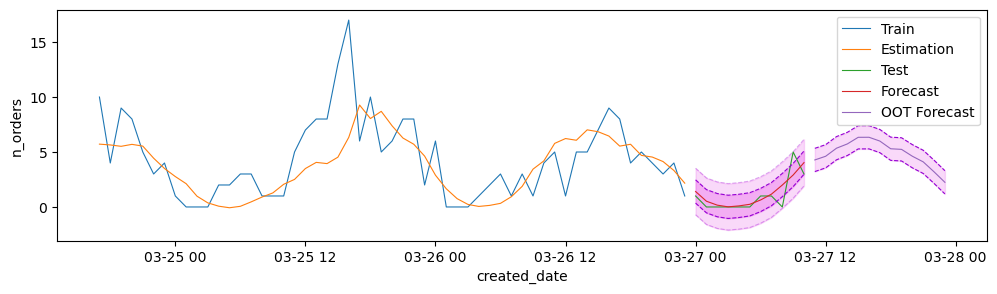

Processing account_id: bfcbb283-4e53-41fd-9b31-aa818f7f23ce, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 369.4087 - val_loss: 626.4096
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 368.8655 - val_loss: 625.4869
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 367.1348 - val_loss: 622.7499
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 363.2619 - val_loss: 617.3768
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 356.9555 - val_loss: 609.6358
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 348.8643 - val_loss: 600.1664
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 340.0139 - val_loss: 589.9873
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 331.1284 - val_loss: 581.1333
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 323.1740 - val_loss: 573.8768
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 317.3657 - val_loss: 567.9031
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 312.8302 - val_loss: 562.3000
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 309.3106 - val_loss: 557.6531
Ep

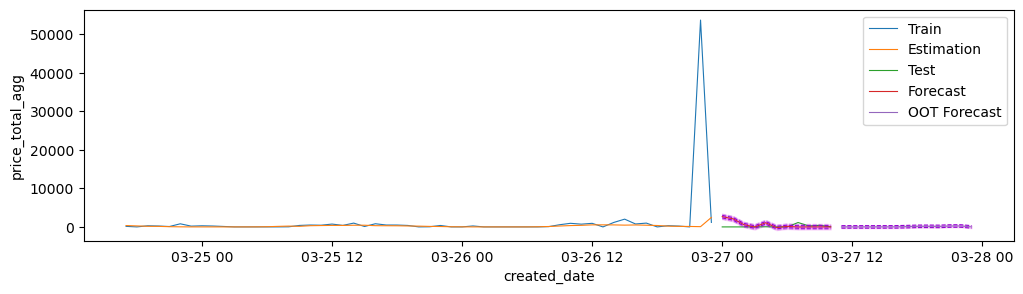

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 1.3713 - val_loss: 1.2483
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 1.0660 - val_loss: 1.1939
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 1.0327 - val_loss: 1.1791
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.0307 - val_loss: 1.1715
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1.0218 - val_loss: 1.1720
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.0082 - val_loss: 1.1671
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 1.0155 - val_loss: 1.1661
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.9877 - val_loss: 1.1630
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1.0049 - val_loss: 1.1597
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 0.9973 - val_loss: 1.1543
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 0.9869 - val_loss: 1.1561
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 0.9824 - val_loss: 1.1563
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 0.9874 - val_loss: 1.1582
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12m

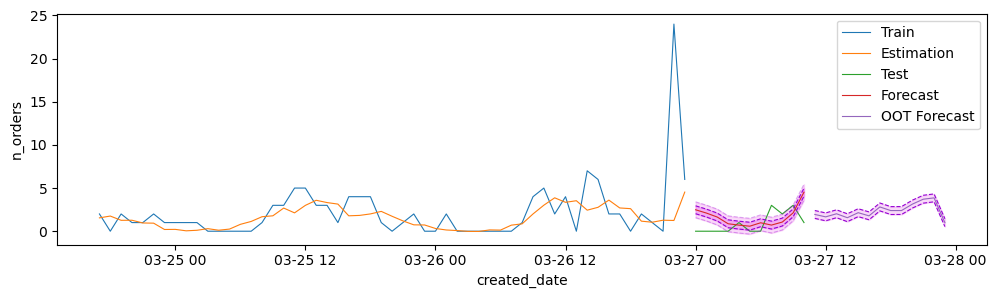

Processing account_id: ad942d1a-15ab-4a0d-83a8-ae82183ece53, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 870.2941 - val_loss: 1051.3409
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 867.1719 - val_loss: 1044.8694
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 857.8837 - val_loss: 1030.4935
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 841.2237 - val_loss: 1008.4738
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 817.8232 - val_loss: 979.7250
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 787.2191 - val_loss: 944.2208
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 750.7482 - val_loss: 901.2571
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 707.6122 - val_loss: 851.9691
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 659.6516 - val_loss: 798.7717
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 609.4064 - val_loss: 744.6345
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 566.9174 - val_loss: 692.6505
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 524.7170 - val_loss: 645.574

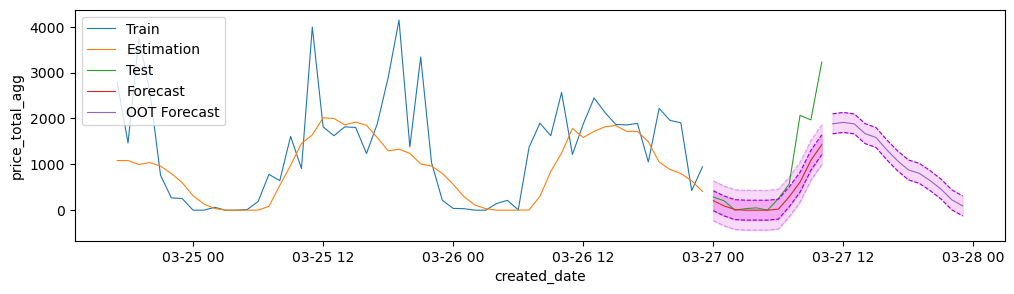

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 6.4736 - val_loss: 5.6473
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 3.7002 - val_loss: 2.5589
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 2.7052 - val_loss: 2.6147
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 2.6355 - val_loss: 2.5517
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 2.6628 - val_loss: 2.5536
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 2.5896 - val_loss: 2.5459
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 2.6168 - val_loss: 2.5609
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 2.6075 - val_loss: 2.5226
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 2.5111 - val_loss: 2.5215
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 2.4845 - val_loss: 2.5166
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 2.5374 - val_loss: 2.5344
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 2.4952 - val_loss: 2.5015
Epoch 13/1000
60/60 - 0s - 2ms/step - loss: 2.5061 - val_loss: 2.5156
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 2.5142 - val_loss: 2.5079


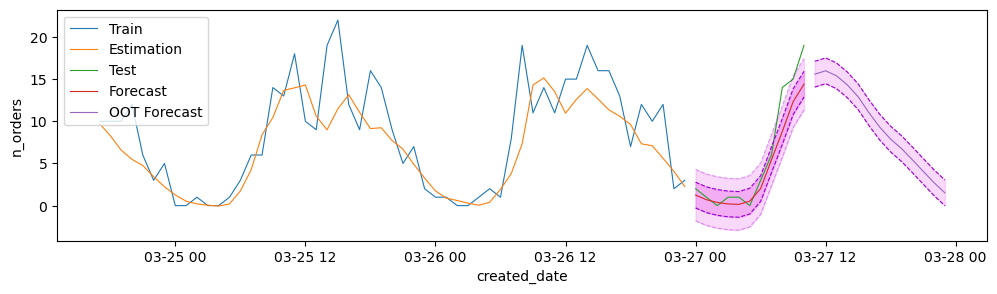

Processing account_id: 789ff5c4-21d8-4ed3-ab64-8b46cf2eba9b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 19ms/step - loss: 255.2278 - val_loss: 209.7214
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 255.0486 - val_loss: 209.5551
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 254.6849 - val_loss: 209.2329
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 254.0607 - val_loss: 208.6894
Epoch 5/1000
60/60 - 0s - 6ms/step - loss: 253.0881 - val_loss: 207.8262
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 251.6757 - val_loss: 206.5957
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 249.8167 - val_loss: 204.8659
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 247.8498 - val_loss: 202.7255
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 245.2177 - val_loss: 200.1796
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 242.5264 - val_loss: 197.1958
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 239.2450 - val_loss: 193.8506
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 236.0307 - val_loss: 190.4205
Ep

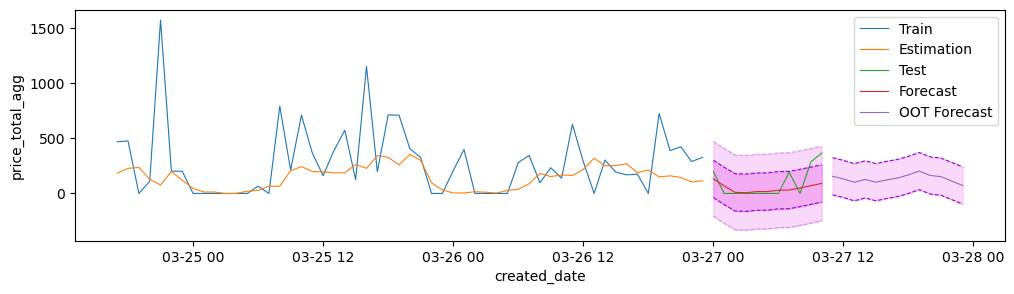

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 2.0581 - val_loss: 1.3332
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.9695 - val_loss: 1.2326
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.8738 - val_loss: 1.1008
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 1.7994 - val_loss: 1.0529
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1.7835 - val_loss: 1.0364
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1.7424 - val_loss: 1.0141
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.7088 - val_loss: 0.9946
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1.6832 - val_loss: 0.9835
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1.6492 - val_loss: 0.9703
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 1.6560 - val_loss: 0.9634
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 1.6239 - val_loss: 0.9600
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 1.6117 - val_loss: 0.9582
Epoch 13/1000
60/60 - 0s - 2ms/step - loss: 1.6170 - val_loss: 0.9586
Epoch 14/1000
60/60 - 0s - 4ms/step - loss: 1.5921 - val_loss: 0.9579


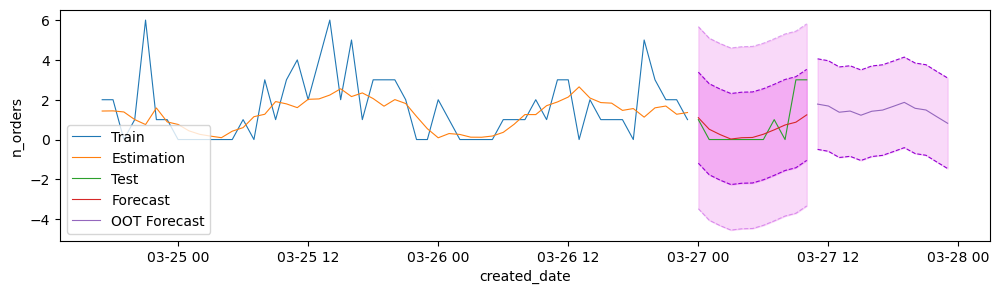

Processing account_id: 0661e926-f219-456e-bde5-612fee6f891c, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 22ms/step - loss: 555.0273 - val_loss: 968.1843
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 554.6204 - val_loss: 967.6880
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 553.7098 - val_loss: 966.7075
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 551.9417 - val_loss: 964.9696
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 548.9105 - val_loss: 962.2363
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 544.6677 - val_loss: 958.4236
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 539.1871 - val_loss: 953.4539
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 532.1180 - val_loss: 947.3837
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 524.5560 - val_loss: 940.2756
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 516.1073 - val_loss: 932.1749
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 506.9497 - val_loss: 923.2838
Epoch 12/1000
60/60 - 0s - 1ms/step - loss: 499.7703 - val_loss: 913.7206
Ep

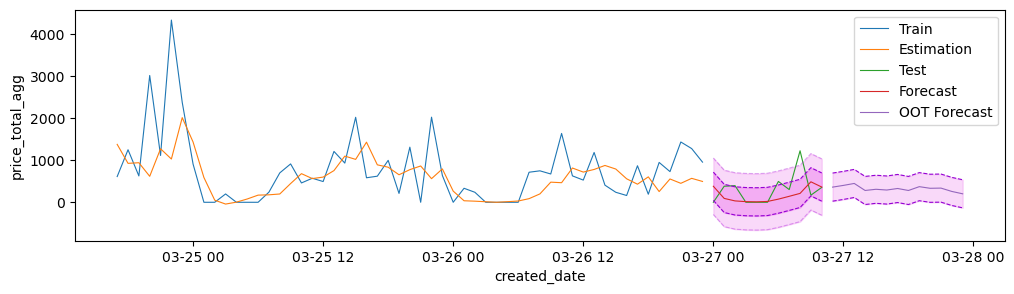

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 36ms/step - loss: 2.6459 - val_loss: 4.9877
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 2.4047 - val_loss: 4.7248
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.2263 - val_loss: 4.4138
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 2.1308 - val_loss: 4.0850
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 2.0846 - val_loss: 3.9598
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 2.0285 - val_loss: 3.8523
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 2.0249 - val_loss: 3.7500
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 1.9790 - val_loss: 3.6549
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 1.9674 - val_loss: 3.5382
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 1.8982 - val_loss: 3.4404
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 1.8685 - val_loss: 3.3501
Epoch 12/1000
60/60 - 0s - 1ms/step - loss: 1.8444 - val_loss: 3.2260
Epoch 13/1000
60/60 - 0s - 1ms/step - loss: 1.7997 - val_loss: 3.1454
Epoch 14/1000
60/60 - 0s - 1ms/step - loss: 1.8166 - val_loss: 3.0758


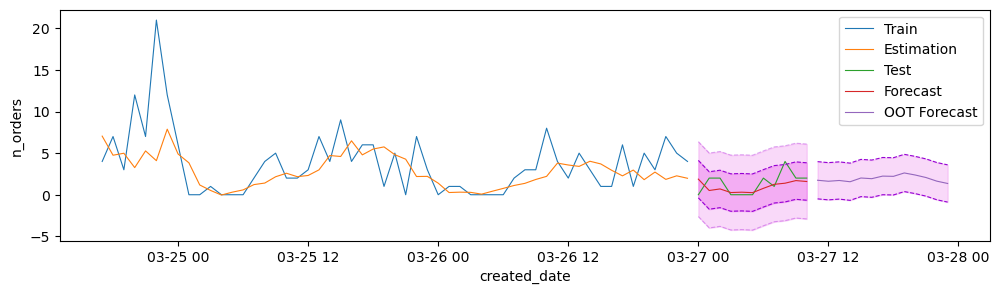

Processing account_id: ca35e88d-d191-4722-b90c-92f4a249869b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 24ms/step - loss: 849.6988 - val_loss: 643.0886
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 848.9774 - val_loss: 642.0345
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 846.9878 - val_loss: 639.3605
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 842.8158 - val_loss: 634.1990
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 835.5945 - val_loss: 625.8948
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 826.0648 - val_loss: 614.9614
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 815.0658 - val_loss: 601.6613
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 803.6530 - val_loss: 587.2978
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 792.0043 - val_loss: 572.3325
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 779.7800 - val_loss: 557.4386
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 769.1149 - val_loss: 542.6465
Epoch 12/1000
60/60 - 0s - 5ms/step - loss: 759.6684 - val_loss: 529.2222
Ep

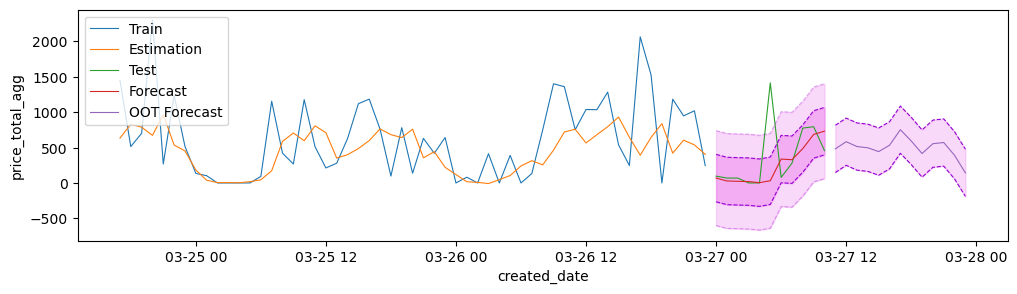

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 31ms/step - loss: 4.1157 - val_loss: 2.9281
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 3.5320 - val_loss: 2.3651
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.9445 - val_loss: 2.0144
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 2.5724 - val_loss: 1.8395
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 2.3994 - val_loss: 1.7882
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 2.3342 - val_loss: 1.7626
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 2.3078 - val_loss: 1.7265
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 2.2662 - val_loss: 1.7215
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 2.1880 - val_loss: 1.6922
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 2.1910 - val_loss: 1.6851
Epoch 11/1000
60/60 - 0s - 7ms/step - loss: 2.1408 - val_loss: 1.6653
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 2.1188 - val_loss: 1.6569
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 2.1502 - val_loss: 1.6494
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 2.0645 - val_loss: 1.6364


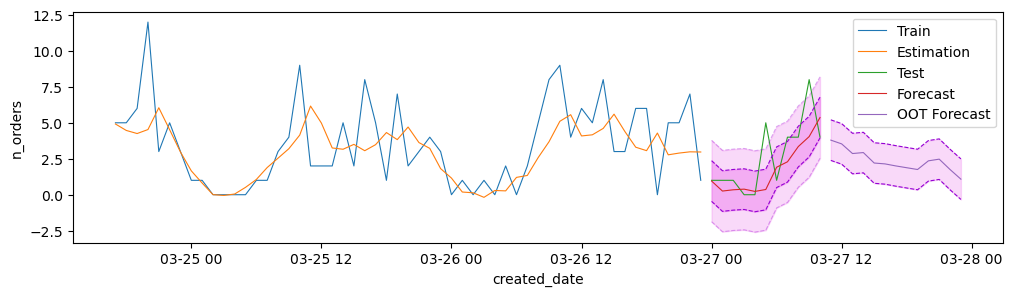

Processing account_id: 478cd985-f4fc-45b4-ac71-bf78cf11e07b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 1007.8493 - val_loss: 561.7208
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1006.6379 - val_loss: 560.9194
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1003.0317 - val_loss: 558.8394
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 995.8895 - val_loss: 555.1298
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 984.6611 - val_loss: 549.6793
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 969.9355 - val_loss: 542.4003
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 951.4561 - val_loss: 533.5944
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 928.7419 - val_loss: 523.2616
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 904.1733 - val_loss: 511.9449
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 877.3077 - val_loss: 499.7054
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 848.1566 - val_loss: 486.8330
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 814.9354 - val_loss: 473.9973

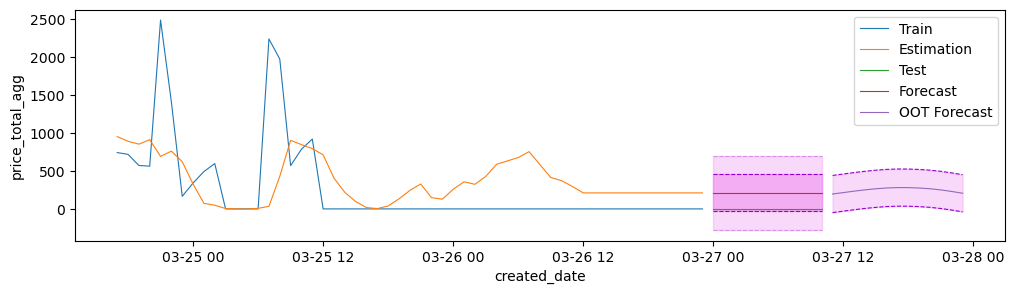

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 4.6027 - val_loss: 2.0733
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 3.6823 - val_loss: 1.7538
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 2.6487 - val_loss: 1.5678
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 2.3894 - val_loss: 1.5124
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 2.3144 - val_loss: 1.4860
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 2.3315 - val_loss: 1.4654
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 2.2316 - val_loss: 1.4433
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 2.2326 - val_loss: 1.4371
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 2.1984 - val_loss: 1.4158
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 2.1899 - val_loss: 1.4160
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 2.1622 - val_loss: 1.3989
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 2.1485 - val_loss: 1.4078
Epoch 13/1000
60/60 - 0s - 5ms/step - loss: 2.1605 - val_loss: 1.4060
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 2.1467 - val_loss: 1.3958


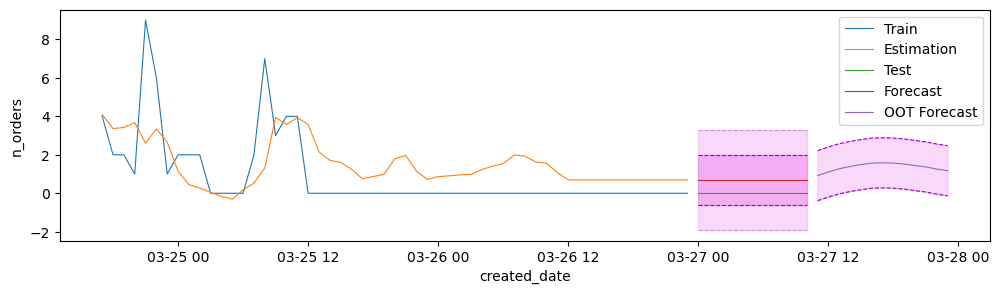

Processing account_id: f4471620-212b-4991-98d3-b498835d0c29, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoch 1/1000
61/61 - 1s - 13ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/st

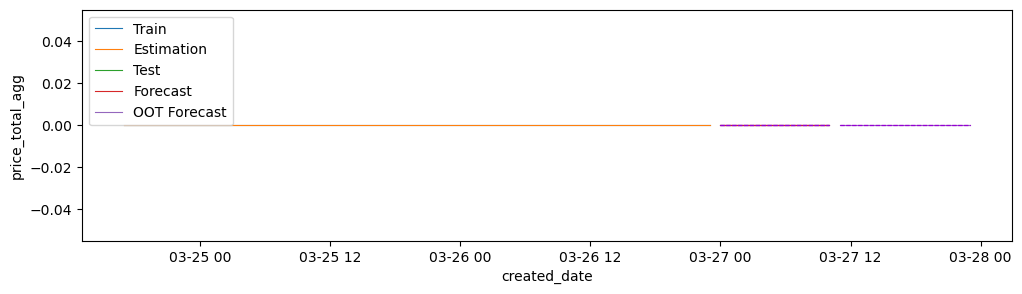

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 1/1000
61/61 - 1s - 12ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━

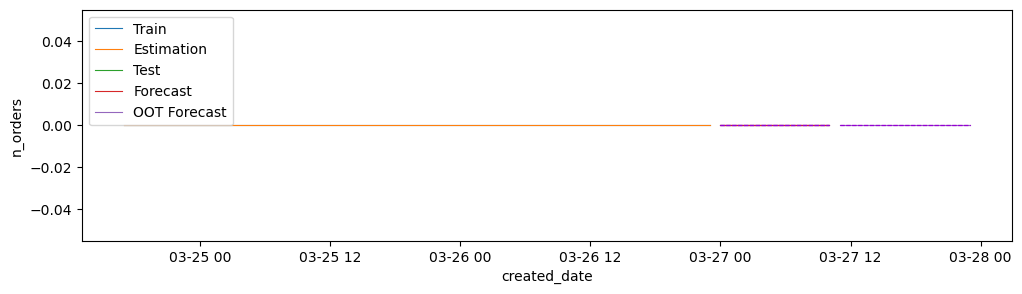

In [10]:
def preprocess_sales_data(account_id, sales_channel_id):
    if sales_channel_id == 'ALL':
        cond = (sales['account_id'] == account_id) & \
               (sales['status'].notna())
    else:
        cond = (sales['account_id'] == account_id) & \
               (sales['sales_channel_id'] == sales_channel_id) & \
               (sales['status'].notna())
    df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
    df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
    df_client = df_client.sort_values('created_date').reset_index(drop=True)
    df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

    df_client_mod = df_client.groupby('created_date').agg(
        price_total_agg=('price_total', 'sum'),
        n_orders=('created_date', 'count')
    )
    df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

    end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
    start_date = end_date - relativedelta(months=LOOKBACK)
    date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
    df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    oot_date_index = pd.Series(df_oot.index, name='created_date')
    combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
    df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    return df_client_mod


def create_lagged_features(df, lags=24):
    lagged_features = [df.shift(l).rename(f'lag_{l}') for l in range(1, lags + 1)]
    df_lag = pd.concat([df, pd.concat(lagged_features, axis=1)], axis=1).dropna().asfreq('h')
    return df_lag


def split_data(df_lag):
    df_train = df_lag.loc[df_lag.index < START_DATE].copy()
    df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
    df_oot = df_lag.loc[df_lag.index > END_DATE].copy()
    return df_train, df_test, df_oot


def train_and_forecast(df_train, df_test, df_full, df_oot, col):
    X_train, y_train = df_train.drop(col, axis=1), df_train[col]
    X_test = df_test.drop(col, axis=1)
    X_full, y_full = df_full.drop(col, axis=1), df_full[col]
    X_oot = df_oot.drop(col, axis=1)
    
    train_mad = y_train.std()
    mad = y_full.std()
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_scaled = np.reshape(X_train_scaled, (X_train.shape[0], 1, X_train.shape[1]))
    X_test_scaled = np.reshape(X_test_scaled, (X_test.shape[0], 1, X_test.shape[1]))
    
    early_stopping = EarlyStopping(patience=3)
    model = Sequential()
    model.add(Input(shape=(1, 24)))
    model.add(LSTM(128, activation='relu', return_sequences=True))
    model.add(Dropout(0.5))
    model.add(Dense(1))
    model.compile(loss='mean_absolute_error', optimizer='adam')
    model.fit(X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALID_SPLIT, shuffle=False, callbacks=early_stopping, verbose=2)
    
    estimations = pd.Series(model.predict(X_train_scaled).squeeze(), index=X_train.index)

    forecast = pd.Series(model.predict(X_test_scaled).squeeze(), index=X_test.index)
    forecast_lower = forecast - CRIT_VALUE*train_mad
    forecast_upper = forecast + CRIT_VALUE*train_mad
    
    scaler = StandardScaler()
    X_full_scaled = np.reshape(scaler.fit_transform(X_full), (X_full.shape[0], 1, X_full.shape[1]))

    early_stopping = EarlyStopping(patience=3)
    oot_model = Sequential()
    oot_model.add(Input(shape=(1, 24)))
    oot_model.add(LSTM(128, activation='relu', return_sequences=True))
    oot_model.add(Dropout(0.5))
    oot_model.add(Dense(1))
    oot_model.compile(loss='mean_absolute_error', optimizer='adam')
    oot_model.fit(X_full_scaled, y_full, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALID_SPLIT, shuffle=False, callbacks=early_stopping, verbose=2)
    
    oot_forecast_ls = []
    oot_forecast_lower_ls = []
    oot_forecast_upper_ls = []
    for i in range(len(X_oot)):
        x_oot = X_oot.iloc[i].to_frame().T
        x_oot_scaled = scaler.transform(x_oot)
        x_oot_scaled = np.reshape(x_oot_scaled, (x_oot.shape[0], 1, x_oot.shape[1]))
        
        x_oot_forecast = oot_model.predict(x_oot_scaled).squeeze()
        oot_forecast_ls.append(x_oot_forecast)
        oot_forecast_lower_ls.append(x_oot_forecast - CRIT_VALUE*mad)
        oot_forecast_upper_ls.append(x_oot_forecast + CRIT_VALUE*mad)
        
        for j, k in list(zip(range(i+1, len(X_oot)), range(len(X_oot)-i-1))):
            X_oot.iloc[j, k] = x_oot_forecast
            
    oot_forecast = pd.Series(oot_forecast_ls, index=X_oot.index).astype(float)
    oot_forecast_lower = pd.Series(oot_forecast_lower_ls, index=X_oot.index)
    oot_forecast_upper = pd.Series(oot_forecast_upper_ls, index=X_oot.index)

    return {
        'estimations': estimations,
        'forecast': forecast,
        'forecast_lower': forecast_lower,
        'forecast_upper': forecast_upper,
        'oot_forecast': oot_forecast,
        'oot_forecast_lower': oot_forecast_lower,
        'oot_forecast_upper': oot_forecast_upper
    }
    
    
def compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col):
    y_train = df_train[col]
    y_test = df_test[col]
    estimations = forecast_results['estimations']
    forecast = forecast_results['forecast']
    forecast_lower = forecast_results['forecast_lower']
    forecast_upper = forecast_results['forecast_upper']
    oot_forecast = forecast_results['oot_forecast']
    oot_forecast_lower = forecast_results['oot_forecast_lower']
    oot_forecast_upper = forecast_results['oot_forecast_upper']
    
    train_mae = mean_absolute_error(df_train[col], estimations)
    train_rmse = root_mean_squared_error(df_train[col], estimations)
    print(f"train RMSE: {train_rmse:.3f}")
    print(f"train MAE:  {train_mae:.3f}")
    test_mae = mean_absolute_error(df_test[col], forecast)
    test_rmse = root_mean_squared_error(df_test[col], forecast)
    print(f"test RMSE: {test_rmse:.3f}")
    print(f"test MAE:  {test_mae:.3f}")
    
    plt.figure(figsize=(12, 3))
    sns.lineplot(y_train.iloc[-5*TEST_SIZE:], lw=0.8, label='Train')
    sns.lineplot(estimations.iloc[-5*TEST_SIZE:], lw=0.8, label='Estimation')
    sns.lineplot(y_test, lw=0.8, label='Test')
    sns.lineplot(forecast, lw=0.8, label='Forecast')
    sns.lineplot(forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
    sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    plt.fill_between(x=forecast.index,
                     y1=forecast_lower,
                     y2=forecast_upper,
                     color='violet',
                     alpha=0.5)
    plt.fill_between(x=forecast.index,
                     y1=2*forecast_lower-forecast,
                     y2=2*forecast_upper-forecast,
                     color='violet',
                     alpha=0.3)
    plt.fill_between(x=oot_forecast.index,
                     y1=oot_forecast_lower,
                     y2=oot_forecast_upper,
                     color='violet',
                     alpha=0.3)
    plt.legend()
    plt.show()
    
    return train_rmse, test_rmse, train_mae, test_mae


def save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict):
    with open(f'sql/time_series/forecast_{account_id}_{sales_channel_id}_ts.sql', 'w') as output_file:
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['forecast'].iloc[i]});
                """
            )
        for i in range(len(df_oot)):
            start_time = df_oot.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast'].iloc[i]});
                """
            )


# Main
if ALL_SALES_CHANNELS:
    id_pairs = set(list(zip(df_count['account_id'], ['ALL']*len(df_count))))
else:
    id_pairs = list(zip(df_count['account_id'], df_count['sales_channel_id']))

summary_dict = {}
for account_id, sales_channel_id in id_pairs:
    print(f'Processing account_id: {account_id}, sales_channel_id: {sales_channel_id}')
    summary_dict[(account_id, sales_channel_id)] = {}

    df_client_mod = preprocess_sales_data(account_id, sales_channel_id)
    df_client_mod.fillna(0, inplace=True)

    forecast_dict = {}
    for n, col in enumerate(['price_total_agg', 'n_orders']):
        print(f'Processing column: {col}')
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {'name': col}

        df_lag = create_lagged_features(df_client_mod[col])
        df_train, df_test, df_oot = split_data(df_lag)
        df_full = pd.concat([df_train, df_test, df_oot], axis=0)

        forecast_results = train_and_forecast(df_train, df_test, df_full, df_oot, col)
        
        forecast_dict[f'dataset_{n}'] = {}
        forecast_dict[f'dataset_{n}'].update(forecast_results)
        
        train_rmse, test_rmse, train_mae, test_mae = compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col)
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae

    save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict)

In [11]:
dataset_0 = pd.DataFrame({k: v['dataset_0'] for k, v in summary_dict.items()}).T
dataset_1 = pd.DataFrame({k: v['dataset_1'] for k, v in summary_dict.items()}).T

In [12]:
summary = (
    pd
    .concat([dataset_0, dataset_1], axis=0)
    .rename({'name': 'dataset'}, axis=1)
    .sort_index()
    .reset_index(names=['account_id', 'sales_channel_id'])
)
summary.to_csv('summary_ml.csv', sep=';')

summary

,account_id,sales_channel_id,dataset,train RMSE,test RMSE,train MAE,test MAE
0,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,ALL,price_total_agg,14958.398801,3251.03835,8568.248154,2374.191806
1,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,ALL,n_orders,37.724039,12.409692,18.41938,8.69651
2,0661e926-f219-456e-bde5-612fee6f891c,ALL,price_total_agg,916.009042,393.022085,358.319244,273.296934
3,0661e926-f219-456e-bde5-612fee6f891c,ALL,n_orders,4.979533,1.218764,1.561272,0.935876
4,0ad2f65b-ee0e-4d50-93e2-84b76282325f,ALL,price_total_agg,4659.565933,1826.220666,2823.583848,977.322236
...,...,...,...,...,...,...,...
69,e2de40dd-743b-4105-9077-3f343fea980d,ALL,n_orders,5.167068,2.626189,3.366763,2.028136
70,f4471620-212b-4991-98d3-b498835d0c29,ALL,price_total_agg,0.0,0.0,0.0,0.0
71,f4471620-212b-4991-98d3-b498835d0c29,ALL,n_orders,0.0,0.0,0.0,0.0
72,f9129295-bb08-4330-b60c-9f0beadda521,ALL,price_total_agg,162189.567319,94963.194195,102651.493021,66592.937488


In [13]:
train_metrics = summary.groupby('dataset')['train MAE'].mean()

train_metrics

dataset
n_orders              3.441847
price_total_agg    3882.674948
Name: train MAE, dtype: object

In [14]:
test_metrics = summary.groupby('dataset')['test MAE'].mean()

test_metrics

dataset
n_orders              1.766654
price_total_agg    2469.291833
Name: test MAE, dtype: object

In [15]:
(train_metrics - test_metrics).abs()

dataset
n_orders              1.675193
price_total_agg    1413.383115
dtype: object